# Práctica 1: Exploratory Data Analysis (EDA)

## 1. Importing the dataset and Cleaning
En esta primera fase vamos a importar las librerías necesarias para el manejo y visualización de los datos (Pandas, Matplotlib y Seaborn, tal y como se ha visto en clase). A continuación, cargaremos nuestro dataset para inspeccionar su tamaño, los tipos de variables que contiene y verificaremos si existen valores nulos (Missing Values) que debamos tratar antes del análisis.

In [ ]:
# Importamos las librerías vistas en clase
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargamos el dataset
df = pd.read_csv('CVD_cleaned.csv')
total_duplicados = df.duplicated().sum()

# Mostramos el tamaño del dataset
print(f"Tamaño del dataset: {df.shape} (filas, columnas)\n")
print(f"Total de filas duplicadas encontradas: {total_duplicados}\n")

# Comprobamos los valores nulos por columna
print("--- Valores Nulos ---")
print(df.isnull().sum())
print("-" * 21)

# Mostramos información general de los tipos de datos (Univariate Non-graphical)
print("\n--- Información del Dataset ---")
df.info()

# Mostramos las 5 primeras filas para verificar la correcta importación
df.head()

Tamaño del dataset: (308854, 19) (filas, columnas)

Total de filas duplicadas encontradas: 80

--- Valores Nulos ---
General_Health                  0
Checkup                         0
Exercise                        0
Heart_Disease                   0
Skin_Cancer                     0
Other_Cancer                    0
Depression                      0
Diabetes                        0
Arthritis                       0
Sex                             0
Age_Category                    0
Height_(cm)                     0
Weight_(kg)                     0
BMI                             0
Smoking_History                 0
Alcohol_Consumption             0
Fruit_Consumption               0
Green_Vegetables_Consumption    0
FriedPotato_Consumption         0
dtype: int64
---------------------

--- Información del Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308854 entries, 0 to 308853
Data columns (total 19 columns):
 #   Column                        Non-Null Count   Dtype 

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,Poor,Within the past 2 years,No,No,No,No,No,No,Yes,Female,70-74,150.0,32.66,14.54,Yes,0.0,30.0,16.0,12.0
1,Very Good,Within the past year,No,Yes,No,No,No,Yes,No,Female,70-74,165.0,77.11,28.29,No,0.0,30.0,0.0,4.0
2,Very Good,Within the past year,Yes,No,No,No,No,Yes,No,Female,60-64,163.0,88.45,33.47,No,4.0,12.0,3.0,16.0
3,Poor,Within the past year,Yes,Yes,No,No,No,Yes,No,Male,75-79,180.0,93.44,28.73,No,0.0,30.0,30.0,8.0
4,Good,Within the past year,No,No,No,No,No,No,No,Male,80+,191.0,88.45,24.37,Yes,0.0,8.0,4.0,0.0


### Conclusiones de la Limpieza de Datos
Tras la importación y la inspección inicial (Univariate Non-graphical), podemos extraer las siguientes conclusiones sobre la estructura de nuestro dataset:
* **Volumen de datos:** Contamos con un dataset robusto de **308.854 registros** (pacientes) y **19 variables** (características). Tenermos 80 filas duplicadas, pero de un dataset de 30000 personas nos deberia dar igual borrarlas o no porque no representa un porcentaje significativo, ademas es posible que de 30000 personas 80 tengan por casualidad las mismas caracteristicas.
* **Calidad de los datos:** Al ejecutar `.isnull().sum()`, comprobamos que **no existe ningún valor nulo (0 NaN)** en todo el dataset. Esto es una excelente noticia, ya que nos ahorra la fase de imputación o eliminación de registros incompletos.
* **Tipos de variables:** Tenemos una mezcla clara de variables numéricas (`float64`, 7 en total) relativas a medidas físicas o de consumo, y variables categóricas (`object`, 12 en total) que representan respuestas de "Sí/No" o clasificaciones médicas.

## Estructura Datos

In [ ]:
# Creamos la lista para el diccionario estructural
diccionario_datos = []

# CAMBIO: Usamos df_clean en lugar de df
for col in df.columns:
    tipo_dato = str(df[col].dtype)
    num_unicos = df[col].nunique()
    nulos = df[col].isnull().sum() 
    
    if tipo_dato == 'object':
        rango = "-" 
        respuestas = ", ".join([str(val) for val in df[col].unique()]) 
    else:
        rango = f"{df[col].min()} a {df[col].max()}"
        respuestas = "-"
        
    diccionario_datos.append({
        'Columna': col,
        'Tipo de dato': tipo_dato,
        'Nulos': nulos,
        'Valores únicos': num_unicos,
        'Rango': rango,
        'Respuestas (Texto)': respuestas
    })

df_diccionario = pd.DataFrame(diccionario_datos)
df_diccionario

,Columna,Tipo de dato,Nulos,Valores únicos,Rango,Respuestas (Texto)
0,General_Health,object,0,5,-,"Poor, Very Good, Good, Fair, Excellent"
1,Checkup,object,0,5,-,"Within the past 2 years, Within the past year,..."
2,Exercise,object,0,2,-,"No, Yes"
3,Heart_Disease,object,0,2,-,"No, Yes"
4,Skin_Cancer,object,0,2,-,"No, Yes"
5,Other_Cancer,object,0,2,-,"No, Yes"
6,Depression,object,0,2,-,"No, Yes"
7,Diabetes,object,0,4,-,"No, Yes, No, pre-diabetes or borderline diabet..."
8,Arthritis,object,0,2,-,"Yes, No"
9,Sex,object,0,2,-,"Female, Male"


## 2. Single variable exploration
En este apartado realizaremos un análisis univariante para comprender la distribución individual de nuestras variables. 
1. **Univariate Non-graphical:** Utilizaremos estadística descriptiva básica (`.describe()`) para entender la tendencia central y dispersión de las variables numéricas, y analizaremos la frecuencia de nuestra variable objetivo categórica (`Heart_Disease`).
2. **Univariate graphical:** Visualizaremos la distribución de una variable numérica continua (como el `BMI`) usando un histograma y un diagrama de caja (*boxplot*) para detectar posibles valores atípicos (*outliers*). También usaremos gráficos de barras (*countplots*) para ver el balanceo de las clases.

### 2.1 EXPLORACIÓN NO GRÁFICA (Univariate Non-graphical)


In [ ]:
# 2.1 EXPLORACIÓN NO GRÁFICA (Univariate Non-graphical)
print("--- Estadística Descriptiva (Variables Numéricas) ---")
# Mostramos la estadística descriptiva transpuesta para facilitar su lectura
display(df.describe().T)

print("\n--- Frecuencia de la Variable Objetivo (Heart_Disease) ---")
# Calculamos el porcentaje exacto de pacientes sanos y enfermos
frecuencia_objetivo = df['Heart_Disease'].value_counts(normalize=True) * 100
print(frecuencia_objetivo.round(2).astype(str) + ' %')

--- Estadística Descriptiva (Variables Numéricas) ---


,count,mean,std,min,25%,50%,75%,max
Height_(cm),308854.0,170.615249,10.658026,91.00,163.00,170.00,178.00,241.00
Weight_(kg),308854.0,83.588655,21.343210,24.95,68.04,81.65,95.25,293.02
BMI,308854.0,28.626211,6.522323,12.02,24.21,27.44,31.85,99.33
Alcohol_Consumption,308854.0,5.096366,8.199763,0.00,0.00,1.00,6.00,30.00
Fruit_Consumption,308854.0,29.835200,24.875735,0.00,12.00,30.00,30.00,120.00
Green_Vegetables_Consumption,308854.0,15.110441,14.926238,0.00,4.00,12.00,20.00,128.00
FriedPotato_Consumption,308854.0,6.296616,8.582954,0.00,2.00,4.00,8.00,128.00



--- Frecuencia de la Variable Objetivo (Heart_Disease) ---
Heart_Disease
No     91.91 %
Yes     8.09 %
Name: proportion, dtype: object


### Conclusiones del Análisis Numérico (Univariate Non-graphical)

Tras generar la estadística descriptiva (`.describe()`) sobre los 308.854 registros del dataset, hemos analizado en profundidad las métricas de tendencia central (media y mediana), dispersión (desviación estándar) y los valores límite. Las conclusiones más relevantes son las siguientes:

**1. Análisis de Medidas Biométricas (Altura, Peso y BMI):**
* **Dispersión Altura vs. Peso:** La altura (`Height_cm`) es una variable muy estable y homogénea en la población, con una media de 170.6 cm y una desviación estándar baja (10.65). Por el contrario, el peso (`Weight_kg`) muestra una alta variabilidad (desviación estándar de 21.34), fluctuando desde los 24.95 kg hasta los 293.02 kg.
* **Valores atípicos extremos:** Los límites de altura (mínimo de 91 cm y máximo de 241 cm) nos confirman que el dataset recoge casos de enanismo y gigantismo. En un contexto médico, estos *outliers* son registros vitales y no deben ser eliminados como si fuesen simples errores de medición.
* **Epidemia de Sobrepeso (BMI):** La mediana (percentil 50%) del Índice de Masa Corporal se sitúa en 27.44. Esto indica matemáticamente que más de la mitad de los pacientes encuestados sufren sobrepeso. Además, el percentil 75% alcanza el 31.85, lo que confirma que al menos una cuarta parte de la muestra padece obesidad clínica (BMI > 30).

**2. Análisis de Hábitos y Sesgos de Encuesta (Alcohol y Dieta):**
* **Asimetría Positiva en el Alcohol:** El consumo de alcohol presenta una mediana de 1.0 y un percentil 25% de 0.0. Esto significa que gran parte de los pacientes apenas bebe. Sin embargo, la media sube engañosamente a 5.09 debido a una desviación estándar altísima (8.19) y un valor máximo de 30. Esto describe perfectamente una distribución asimétrica: un pequeño grupo de bebedores diarios arrastra la media matemática hacia arriba.
* **Sesgo de Redondeo en la Fruta:** Observamos un fenómeno muy peculiar en el consumo de fruta (`Fruit_Consumption`). La media es 29.83, y tanto la mediana (50%) como el percentil 75% se estancan exactamente en el valor 30.0. Este patrón estadístico sugiere un claro sesgo humano a la hora de responder la encuesta: la inmensa mayoría de las personas redondeó su respuesta mental a "una vez al día", lo que equivale a 30 veces al mes.
* **Comida Basura (Patatas Fritas):** El consumo de patatas fritas (`FriedPotato_Consumption`) revela que el 75% de las personas las consume de forma moderada (8 veces o menos al mes). Sin embargo, el valor máximo reportado es de 128 veces al mes  (más de 4 raciones diarias), lo que ayuda a perfilar, junto al peso máximo, a los pacientes con el mayor riesgo cardiovascular.

### 2.2 EXPLORACIÓN GRÁFICA (Univariate graphical)

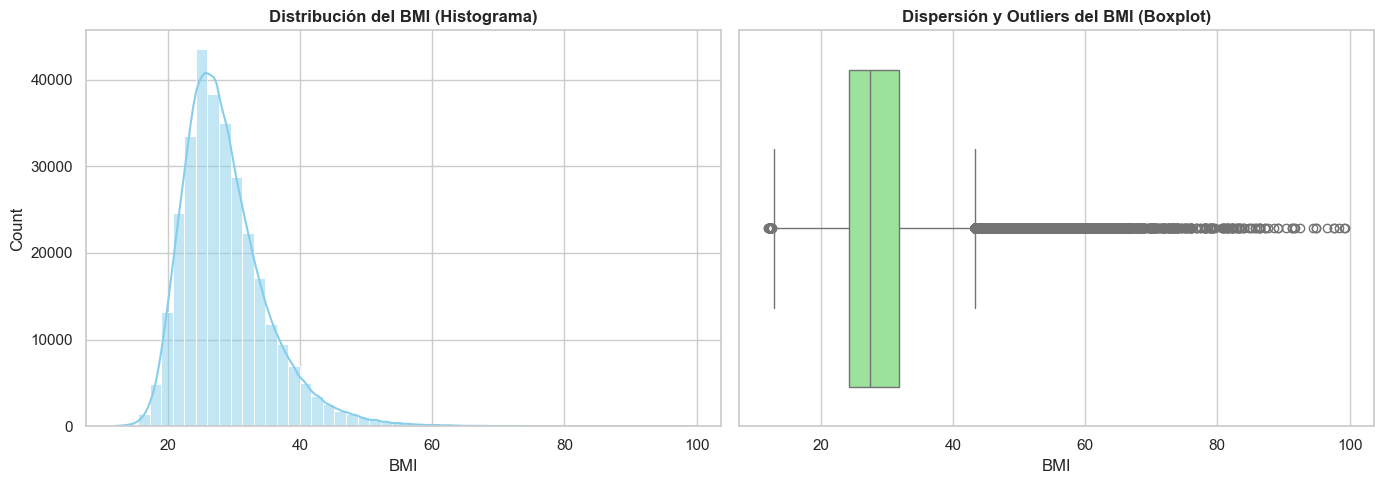

C:\Users\es62022260\AppData\Local\Temp\ipykernel_9448\3433873735.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=variable, ax=axes[i], palette='pastel')
C:\Users\es62022260\AppData\Local\Temp\ipykernel_9448\3433873735.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=variable, ax=axes[i], palette='pastel')
C:\Users\es62022260\AppData\Local\Temp\ipykernel_9448\3433873735.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=variable, ax=axes[i], palette='pastel')
C:\Users\es62022260\AppData\Local\

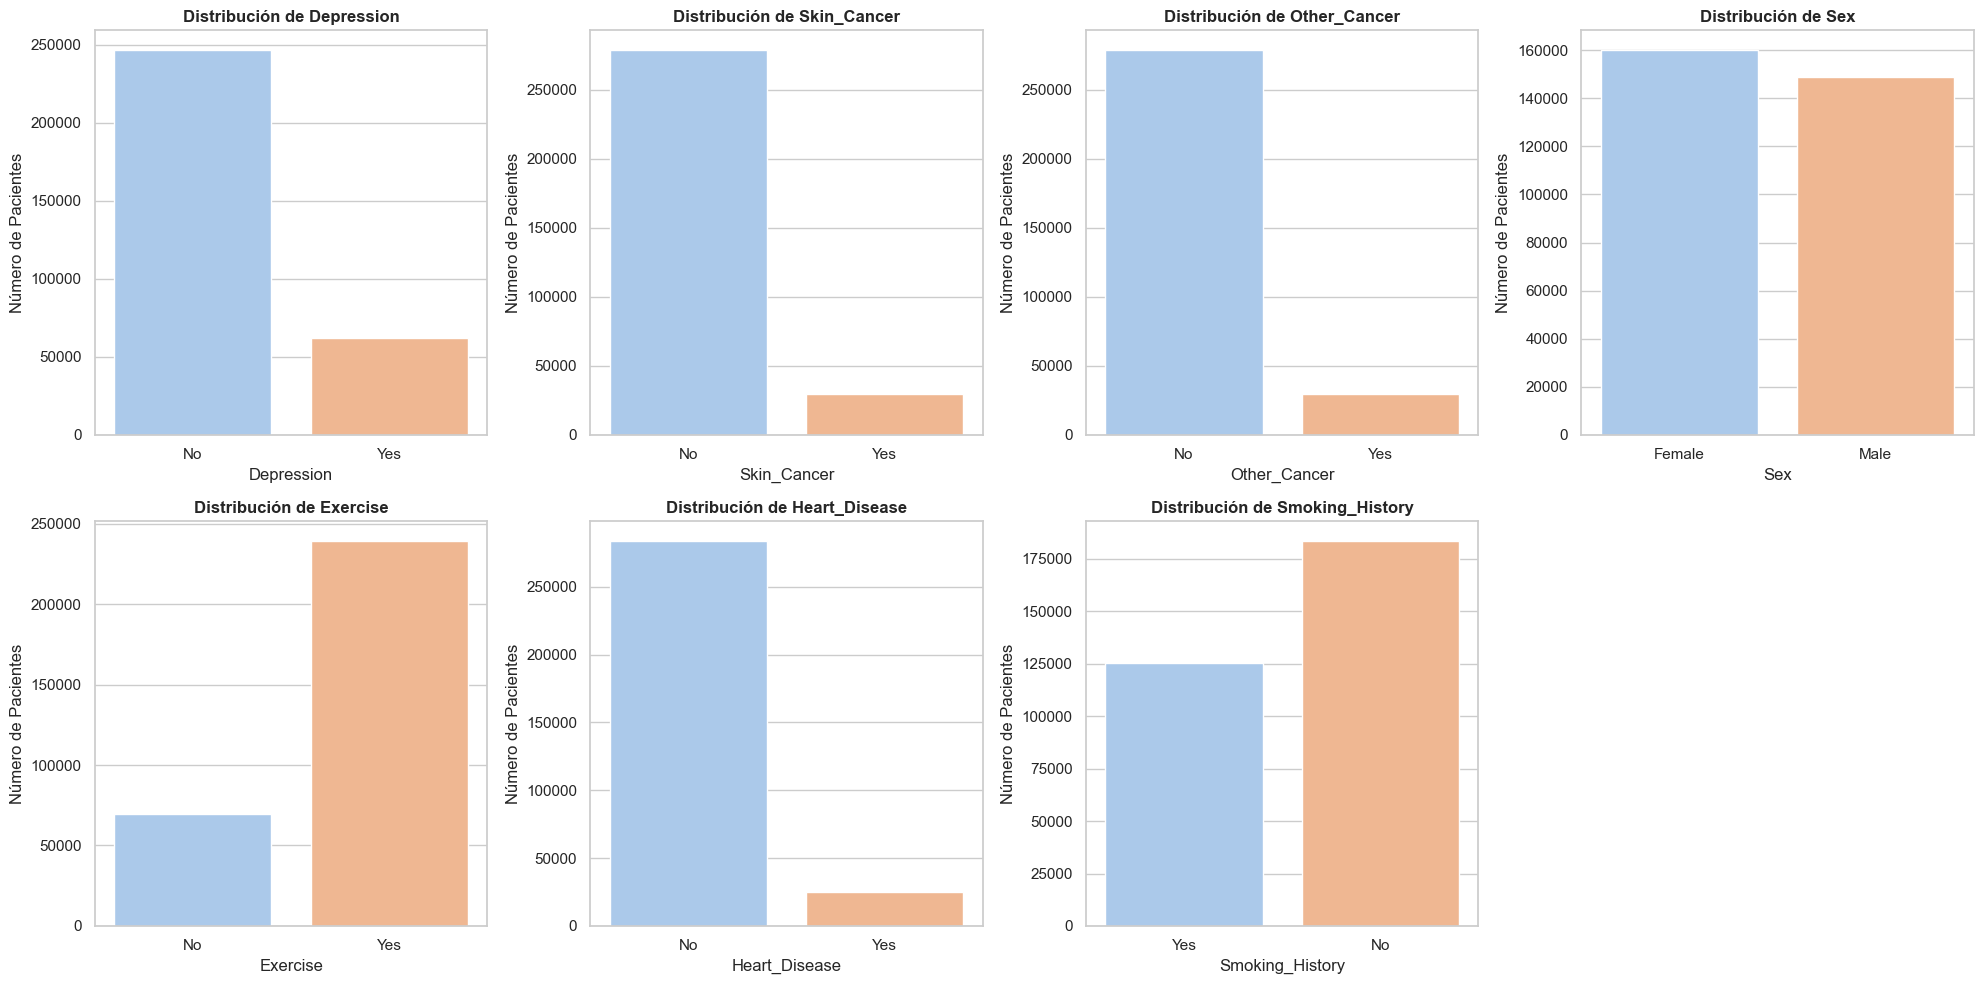

In [ ]:
# 2.2 EXPLORACIÓN GRÁFICA (Univariate graphical)
# Configuramos el estilo de los gráficos como en las prácticas
sns.set_theme(style="whitegrid")

# Inicializamos una figura con 2 subgráficos para la variable numérica 'BMI'
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma para evaluar la simetría y forma de la distribución
sns.histplot(df['BMI'], bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribución del BMI (Histograma)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('BMI')

# Boxplot para identificar visualmente la presencia de outliers
sns.boxplot(x=df['BMI'], ax=axes[1], color='lightgreen')
axes[1].set_title('Dispersión y Outliers del BMI (Boxplot)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('BMI')

plt.tight_layout()
plt.show()

# Creamos una figura con 2 filas y 4 columnas (espacio para 8 gráficas)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# Aplanamos la matriz de ejes
axes = axes.flatten()

# Tu lista con las 7 variables
variables_extra = ['Depression', 'Skin_Cancer', 'Other_Cancer', 'Sex', 'Exercise', 'Heart_Disease', 'Smoking_History']

# Bucle para dibujar automáticamente las 7 gráficas
for i, variable in enumerate(variables_extra):
    sns.countplot(data=df, x=variable, ax=axes[i], palette='pastel')
    axes[i].set_title(f'Distribución de {variable}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Número de Pacientes')

# Como tenemos 8 huecos y solo 7 variables, borramos el último hueco vacío (el índice 7)
fig.delaxes(axes[7])

plt.tight_layout()
plt.show()

### Conclusiones del Análisis Gráfico (Univariate graphical)

Al visualizar las distribuciones de nuestras variables, confirmamos de forma gráfica los patrones detectados en el análisis numérico previo:

**1. Distribución de Variables Numéricas (Ej. BMI):**
* **Histograma (Simetría):** La campana del Índice de Masa Corporal (BMI) no está perfectamente centrada. Presenta una clara **asimetría positiva** (una "cola" que se alarga hacia la derecha). Vemos que el gran bloque de pacientes se concentra en la franja de 25 a 30, lo que visualiza de forma muy clara la tendencia al sobrepeso en la muestra.
    * Menos de 18.5: Bajo peso.

    * 18.5 a 24.9: Peso normal o saludable.

    * 25.0 a 29.9: Sobrepeso.

    * 30.0 o más: Obesidad.
* **Boxplot (Valores Atípicos):** El diagrama de caja de la derecha revela una densa nube de puntos por encima del bigote superior (llegando a valores cercanos a 100). En un análisis médico, es crucial entender que estos *outliers* no son errores informáticos, sino pacientes reales con casos de obesidad severa o mórbida.
    * La Caja (El bloque verde): Representa al 50% de las personas que están justo en el medio de la fila. Es la "gran masa" normal.

    * La línea dentro de la caja: Es la Mediana (el paciente que está exactamente en el centro de la fila).

    * Los Bigotes (Las líneas que salen de la caja): Marcan el límite matemático de lo que se considera un valor "estadísticamente normal".

    * Los Puntitos Negros: Son los Outliers (valores atípicos). Son los pacientes que se salen de los bigotes. En el caso del BMI, como los puntitos están por la parte de arriba, representan a los pacientes que sufren de obesidad mórbida o severa.

**2. Distribución de Variables Categóricas:**
* **Enfermedad Cardíaca (`Heart_Disease`):** El gráfico de barras hace evidente el **fuerte desbalanceo de clases**. La barra verde de pacientes sanos ("No") aplasta visualmente a la barra roja de enfermos ("Yes"). Esto nos advierte de que el algoritmo predictivo tendrá muchos ejemplos para aprender a detectar sanos, pero muy pocos para aprender a detectar enfermos.
* **Tabaquismo (`Smoking_History`):** A diferencia de la enfermedad cardíaca, el historial de tabaquismo presenta una distribución mucho más equilibrada poblacionalmente, con un volumen muy representativo de personas que sí han fumado. Esto la convierte en una variable excelente para cruzar datos en el siguiente paso.
* **Cáncer (`Skin_Cancer` y `Other_Cancer`):** Tal y como ocurre con la enfermedad cardíaca, estas variables presentan un desbalanceo extremo hacia la clase negativa ("No"). Esto es coherente con una base de datos de población general, donde la incidencia de estas enfermedades es baja.
* **Depresión (`Depression`):** A diferencia de los casos de cáncer, la barra de casos positivos ("Yes") en depresión es visiblemente más alta, revelando que una proporción considerable de la muestra sufre o ha sufrido esta patología psicológica, siendo la comorbilidad más frecuente de las analizadas.
* **Equilibrio Demográfico (`Sex`):** El gráfico revela un balance poblacional casi perfecto entre hombres y mujeres, con una ligerísima mayoría femenina. Esto es una noticia excelente para el diseño de nuestro futuro modelo de *Machine Learning*, ya que nos garantiza que el algoritmo no aprenderá sesgos de género provocados por una falta de datos.
* **Actividad Física (`Exercise`):** La distribución muestra que la mayoría de los encuestados afirma realizar ejercicio físico ("Yes"). Sin embargo, existe un bloque nada despreciable de pacientes sedentarios ("No"). Esta variable de estilo de vida será fundamental en etapas posteriores para evaluar su impacto real como factor protector frente al riesgo cardiovascular.

### 2.3 Visión Global Numérica (Histogramas Múltiples)
Para finalizar la exploración univariante, generamos una matriz de histogramas que nos permite visualizar de un solo vistazo la distribución general de todas las variables numéricas presentes en el dataset.

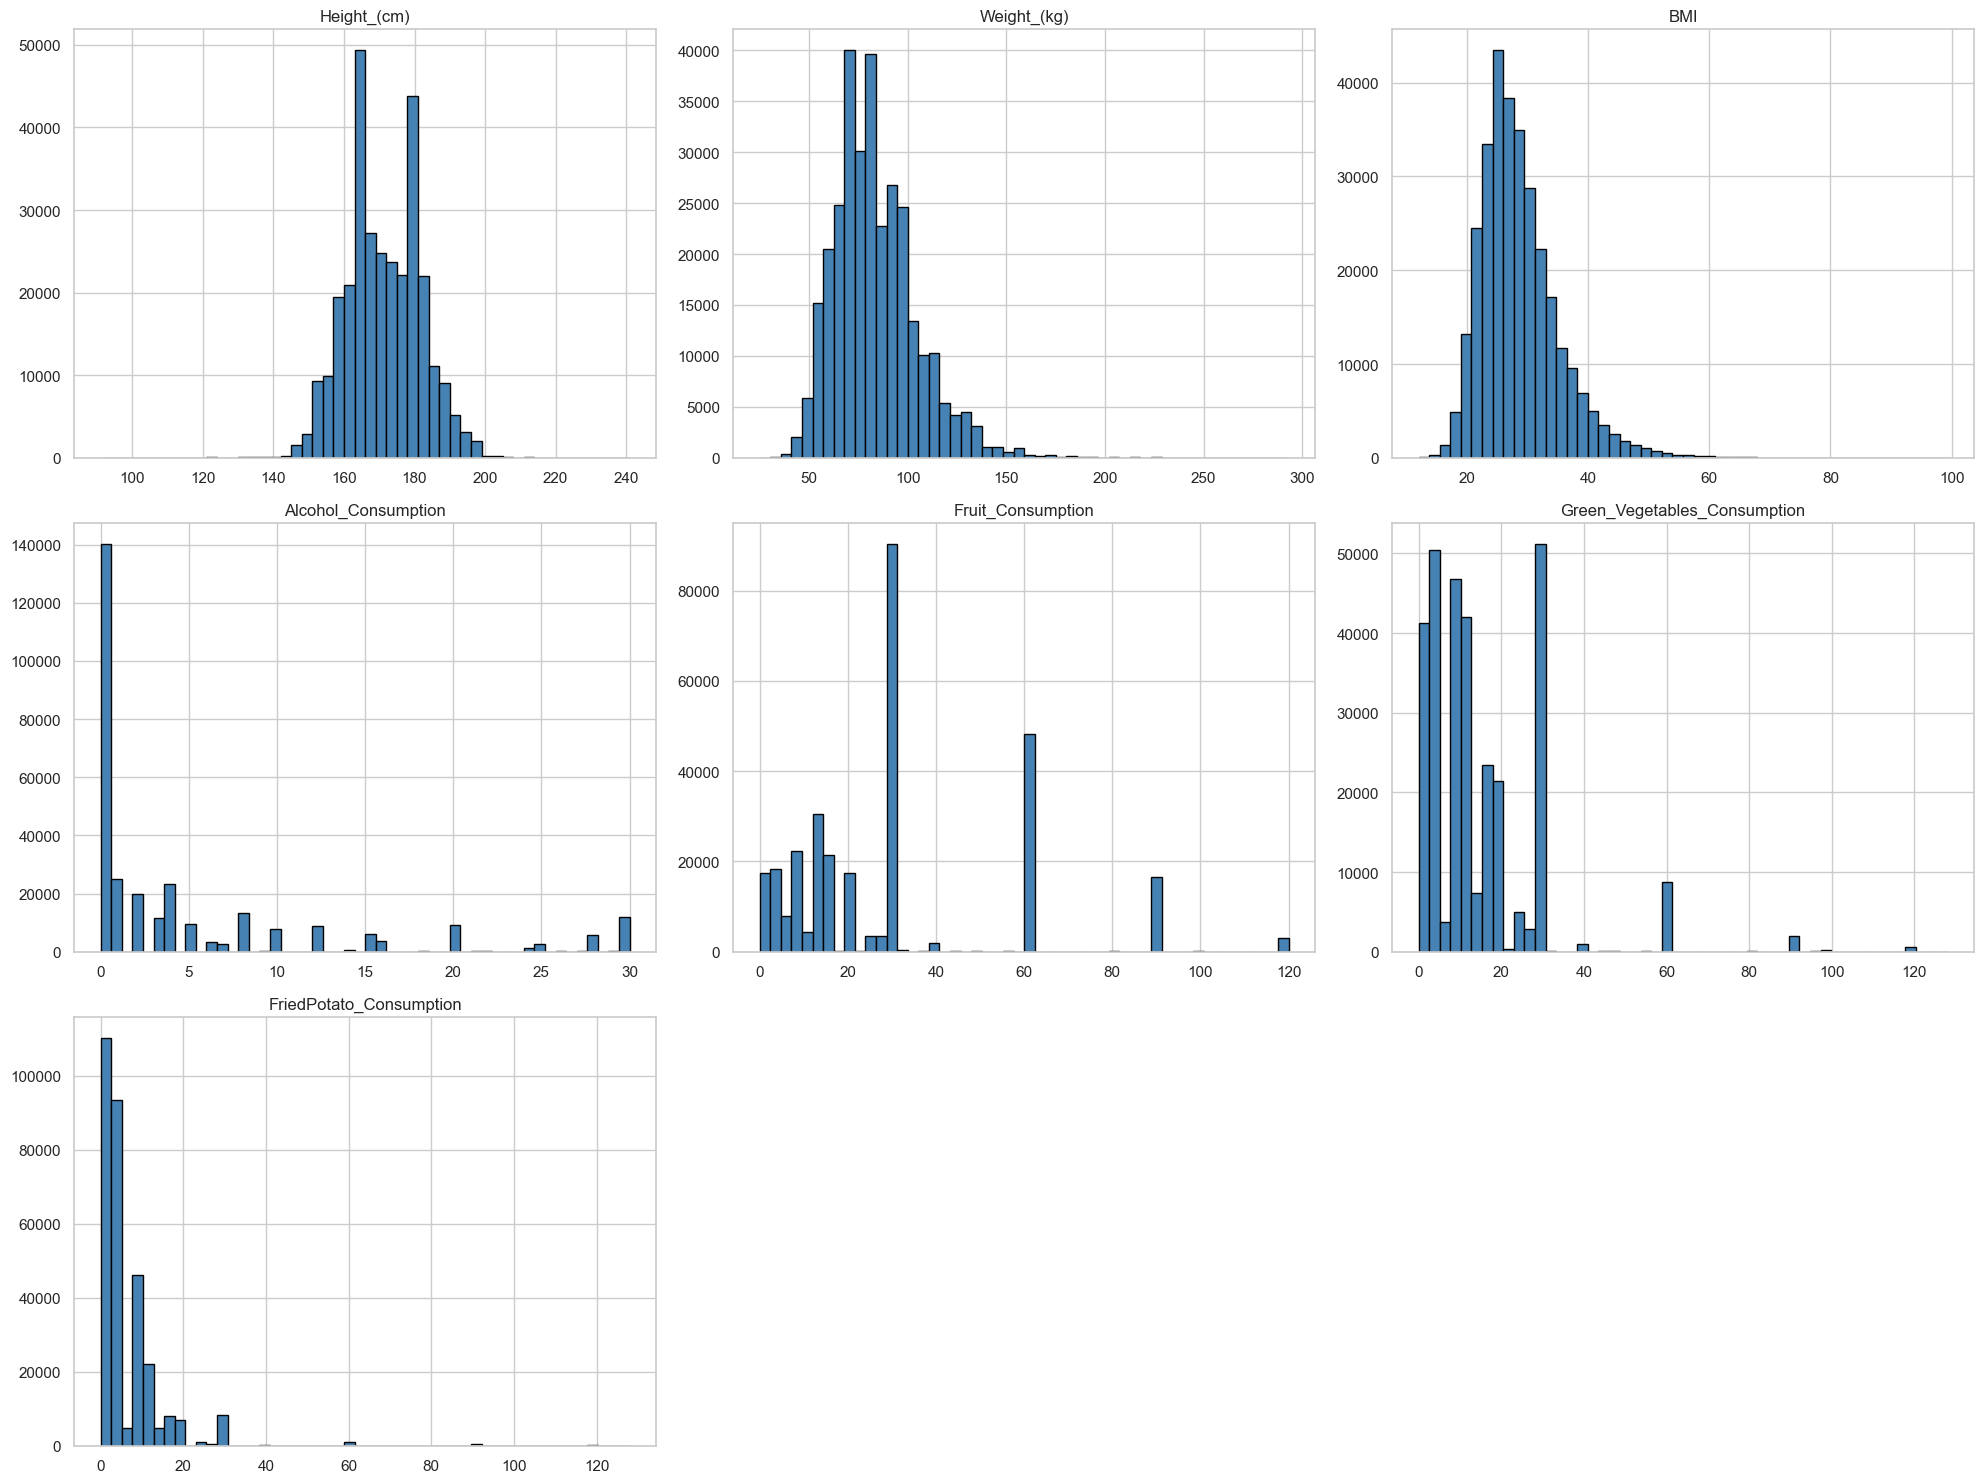

In [ ]:
# Generamos un histograma para todas las variables numéricas a la vez
# figsize=(20, 15) asegura que la imagen sea grande y los gráficos no se pisen
df.hist(bins=50, figsize=(20, 15), color='steelblue', edgecolor='black')

# Ajustamos el espaciado y mostramos
plt.tight_layout()
plt.show()

### Conclusiones de la Visión Global Numérica

El panel de histogramas múltiples nos ofrece una radiografía completa de todas las variables continuas del dataset, permitiéndonos confirmar visualmente los patrones detectados en el análisis numérico:

* **Distribución Normal (Campana de Gauss):** La altura (`Height_(cm)`) es la única variable que presenta una distribución normal casi perfecta, simétrica y centrada en torno a los 170 cm. 
* **Asimetría Positiva en Variables Biométricas:** Tanto el peso (`Weight_(kg)`) como el `BMI` muestran una clara cola hacia la derecha. Esto visualiza perfectamente cómo el volumen de pacientes se concentra en la zona de sobrepeso, pero se extiende con una larga cola hacia casos de obesidad severa.
* **Sesgos Psicológicos en las Encuestas:** Las gráficas de consumo (`Fruit_Consumption` y `Green_Vegetables_Consumption`) revelan un patrón muy peculiar en forma de "peine" o picos aislados. Los pacientes no responden con números exactos (ej. 27 o 31), sino que redondean drásticamente a múltiplos de 10 o 15, generando un pico masivo exacto en el valor 30 (equivalente a "una vez al día").
* **Abstinencia Mayoritaria:** El gráfico de `Alcohol_Consumption` ratifica que la inmensa mayoría de la población se concentra en el valor absoluto de 0, confirmando la fuerte asimetría que ya habíamos detectado en la desviación estándar.

## 3. Multivariable Exploration
En este apartado exploraremos la relación bivariante entre pares de variables de nuestro dataset para detectar patrones conjuntos. 

Comenzaremos con la aproximación **Multivariate Non-graphical**:
1. **Matriz de Correlación Lineal (Pearson):** Nos permitirá medir matemáticamente el grado de relación lineal entre las variables continuas.
2. **Tablas de Contingencia (Crosstab):** Evaluaremos cómo se distribuyen las frecuencias conjuntas de dos variables categóricas, cruzando nuestra variable objetivo (`Heart_Disease`) con un factor de riesgo como el tabaquismo (`Smoking_History`).

### 3.1 ANÁLISIS BIVARIANTE NUMÉRICO (Multivariate Non-graphical)


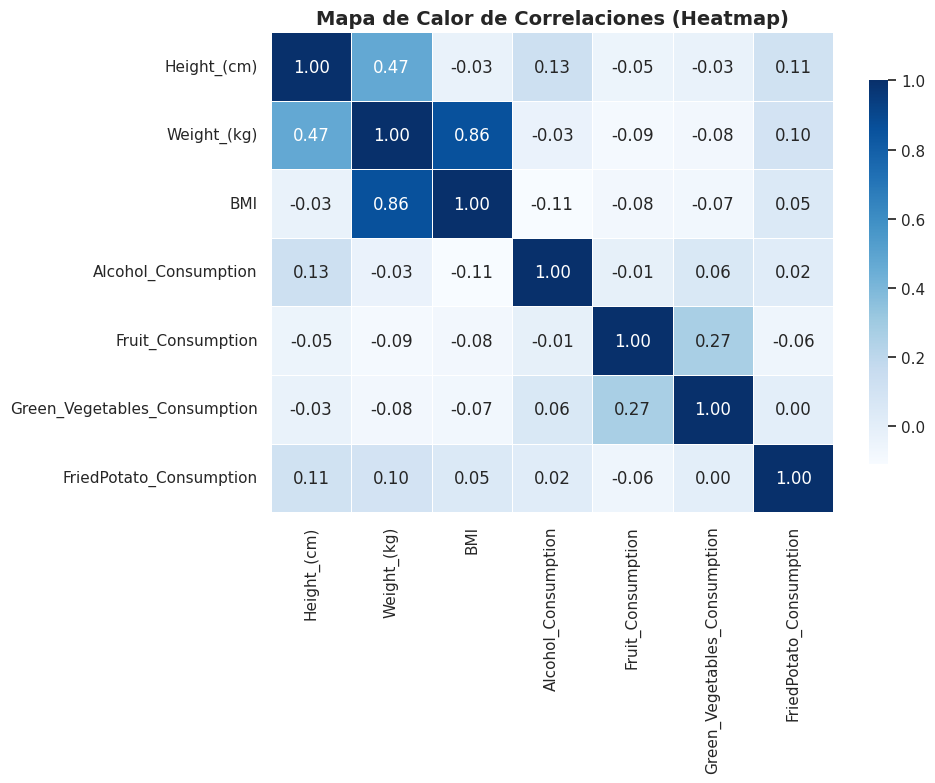

--- Tabla de Contingencia Absoluta: Tabaco vs Enfermedad ---


Heart_Disease,No,Yes,All
Smoking_History,,,
No,173203,10387,183590
Yes,110680,14584,125264
All,283883,24971,308854



--- Proporciones Relativas por Fila (%) ---


Heart_Disease,No,Yes
Smoking_History,,
No,94.34228443815023 %,5.657715561849773 %
Yes,88.35738919402223 %,11.642610805977775 %


In [ ]:
# 3.1 ANÁLISIS BIVARIANTE NUMÉRICO (Multivariate Non-graphical)

# 1. Matriz de Correlación de Pearson
plt.figure(figsize=(10, 8))
# Seleccionamos solo las variables numéricas y calculamos su correlación
corr_matrix = df.select_dtypes(include=['float64', 'int64']).corr()

# Dibujamos el Heatmap con Seaborn
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt='.2f', linewidths=0.5, 
            cbar_kws={"shrink": .8})
plt.title('Mapa de Calor de Correlaciones (Heatmap)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 2. Tabla de Contingencia Absoluta (Frecuencias reales)
print("--- Tabla de Contingencia Absoluta: Tabaco vs Enfermedad ---")
tabla_contingencia = pd.crosstab(df['Smoking_History'], df['Heart_Disease'], margins=True)
display(tabla_contingencia.style.background_gradient(cmap='Blues', axis=None))

print("\n--- Proporciones Relativas por Fila (%) ---")
# 3. Tabla de Porcentajes 
tabla_porcentajes = pd.crosstab(df['Smoking_History'], df['Heart_Disease'], normalize='index') * 100

# Coloreamos con tonos azules para mantener la coherencia visual
porcentajes_estilizados = tabla_porcentajes.style.background_gradient(cmap='Blues', axis=None) \
                                                 .format(precision=2, formatter="{} %")
display(porcentajes_estilizados)

### 3.2 ANÁLISIS BIVARIANTE GRÁFICO (Multivariate graphical)

Tras identificar matemáticamente las relaciones entre las variables, procedemos a visualizarlas.
1. **Relaciones Numéricas (Scatter Plot):** Observaremos la relación directa detectada entre el Peso y el BMI.
2. **Relaciones Numérico-Categóricas (Boxplot):** Evaluaremos cómo varía el BMI dependiendo de si el paciente sufre enfermedad cardíaca.
3. **Relaciones Categóricas (Bar Plot agrupado):** Visualizaremos el impacto del tabaco en la enfermedad cardíaca que cuantificamos en la tabla de contingencia.

C:\Users\es62022260\AppData\Local\Temp\ipykernel_9448\3485212677.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Heart_Disease', y='BMI', palette=['#2ca02c', '#d62728'], ax=axes[1])


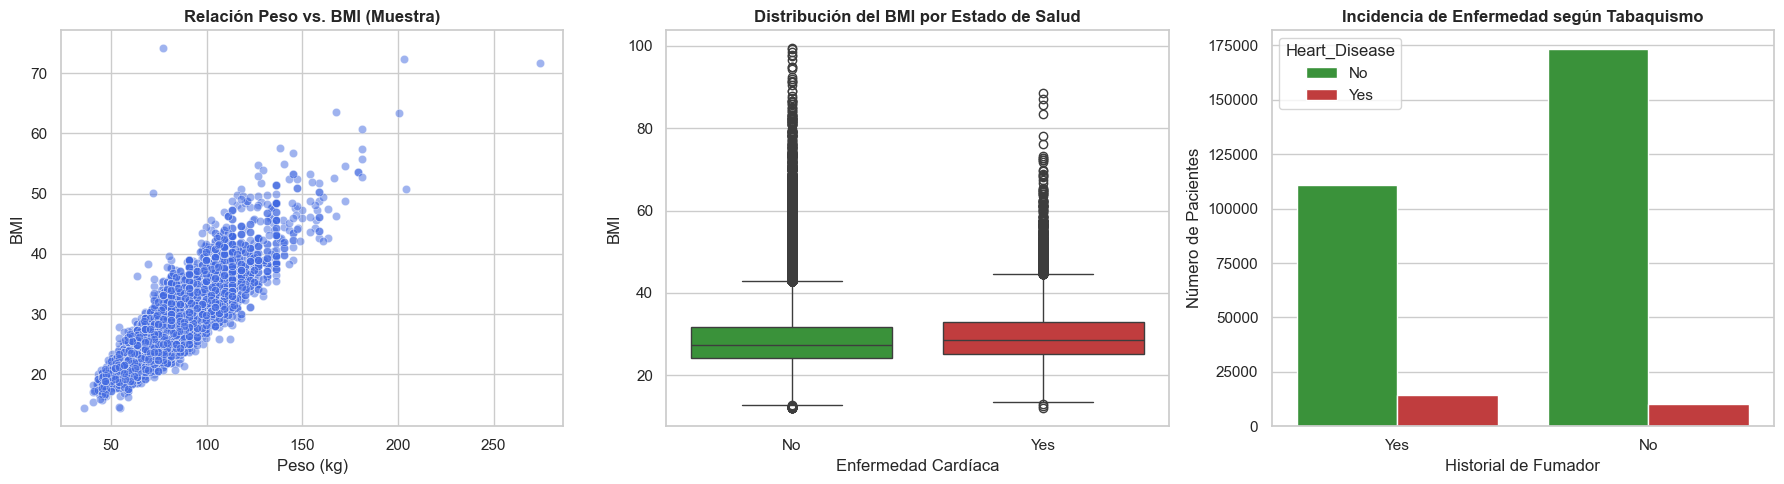

In [ ]:
# 3.2 EXPLORACIÓN GRÁFICA BIVARIANTE (Multivariate graphical)
sns.set_theme(style="whitegrid")

# Creamos una figura con 1 fila y 3 columnas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Scatter Plot (Dispersión): Peso vs. BMI
# Tomamos una muestra aleatoria de 5,000 datos para que el gráfico no sea un manchón negro ilegible
muestra_scatter = df.sample(5000, random_state=42)
sns.scatterplot(data=muestra_scatter, x='Weight_(kg)', y='BMI', alpha=0.5, color='royalblue', ax=axes[0])
axes[0].set_title('Relación Peso vs. BMI (Muestra)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Peso (kg)')
axes[0].set_ylabel('BMI')

# 2. Boxplot cruzado: Enfermedad vs. BMI
sns.boxplot(data=df, x='Heart_Disease', y='BMI', palette=['#2ca02c', '#d62728'], ax=axes[1])
axes[1].set_title('Distribución del BMI por Estado de Salud', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Enfermedad Cardíaca')

# 3. Countplot agrupado: Tabaco vs. Enfermedad
sns.countplot(data=df, x='Smoking_History', hue='Heart_Disease', palette=['#2ca02c', '#d62728'], ax=axes[2])
axes[2].set_title('Incidencia de Enfermedad según Tabaquismo', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Historial de Fumador')
axes[2].set_ylabel('Número de Pacientes')

plt.tight_layout()
plt.show()

### Conclusiones del Análisis Gráfico Bivariante (Multivariate graphical)

La representación visual de las parejas de variables confirma y amplía los hallazgos numéricos obtenidos en las matrices y tablas de contingencia:

**1. Relación Numérica Directa (Scatter Plot):**
* El gráfico de dispersión entre Peso y BMI dibuja una clarísima tendencia ascendente. Esto confirma visualmente la fuerte correlación lineal positiva (0.866) que detectamos en la matriz de Pearson. Se observa cómo a medida que aumenta el peso de los pacientes, el índice de masa corporal se dispara en una proporción directa.

**2. Impacto Biométrico en la Salud (Boxplot):**
* Al cruzar una variable continua (BMI) con nuestra variable objetivo categórica (Enfermedad Cardíaca), descubrimos un patrón interesante. La "caja" roja (pacientes enfermos) está ligeramente más elevada que la caja verde (pacientes sanos). Esto significa que la mediana del BMI y el percentil 75% son mayores en el grupo con problemas cardíacos, sugiriendo que un mayor índice de masa corporal está asociado a una mayor presencia de la enfermedad.
* En ambos grupos se mantienen las largas colas de *outliers* superiores (obesidad mórbida), confirmando que esta condición existe independientemente de si el paciente ha desarrollado ya una cardiopatía o no.

**3. Factores de Riesgo Visualizados (Bar Plot Agrupado):**
* El gráfico de barras agrupadas escenifica el salto de riesgo que calculamos en la tabla de porcentajes. 
* Aunque la inmensa mayoría de los pacientes en ambos grupos están sanos (barras verdes altísimas debido al desbalanceo de clases), la atención debe fijarse en las barras rojas. La barra roja de enfermos en el grupo de fumadores ("Yes") es considerablemente más alta que la del grupo de no fumadores ("No"), a pesar de que el número total de no fumadores en el dataset es mayor. Esto evidencia visualmente que el tabaquismo incrementa drásticamente la proporción de enfermedad cardiovascular.

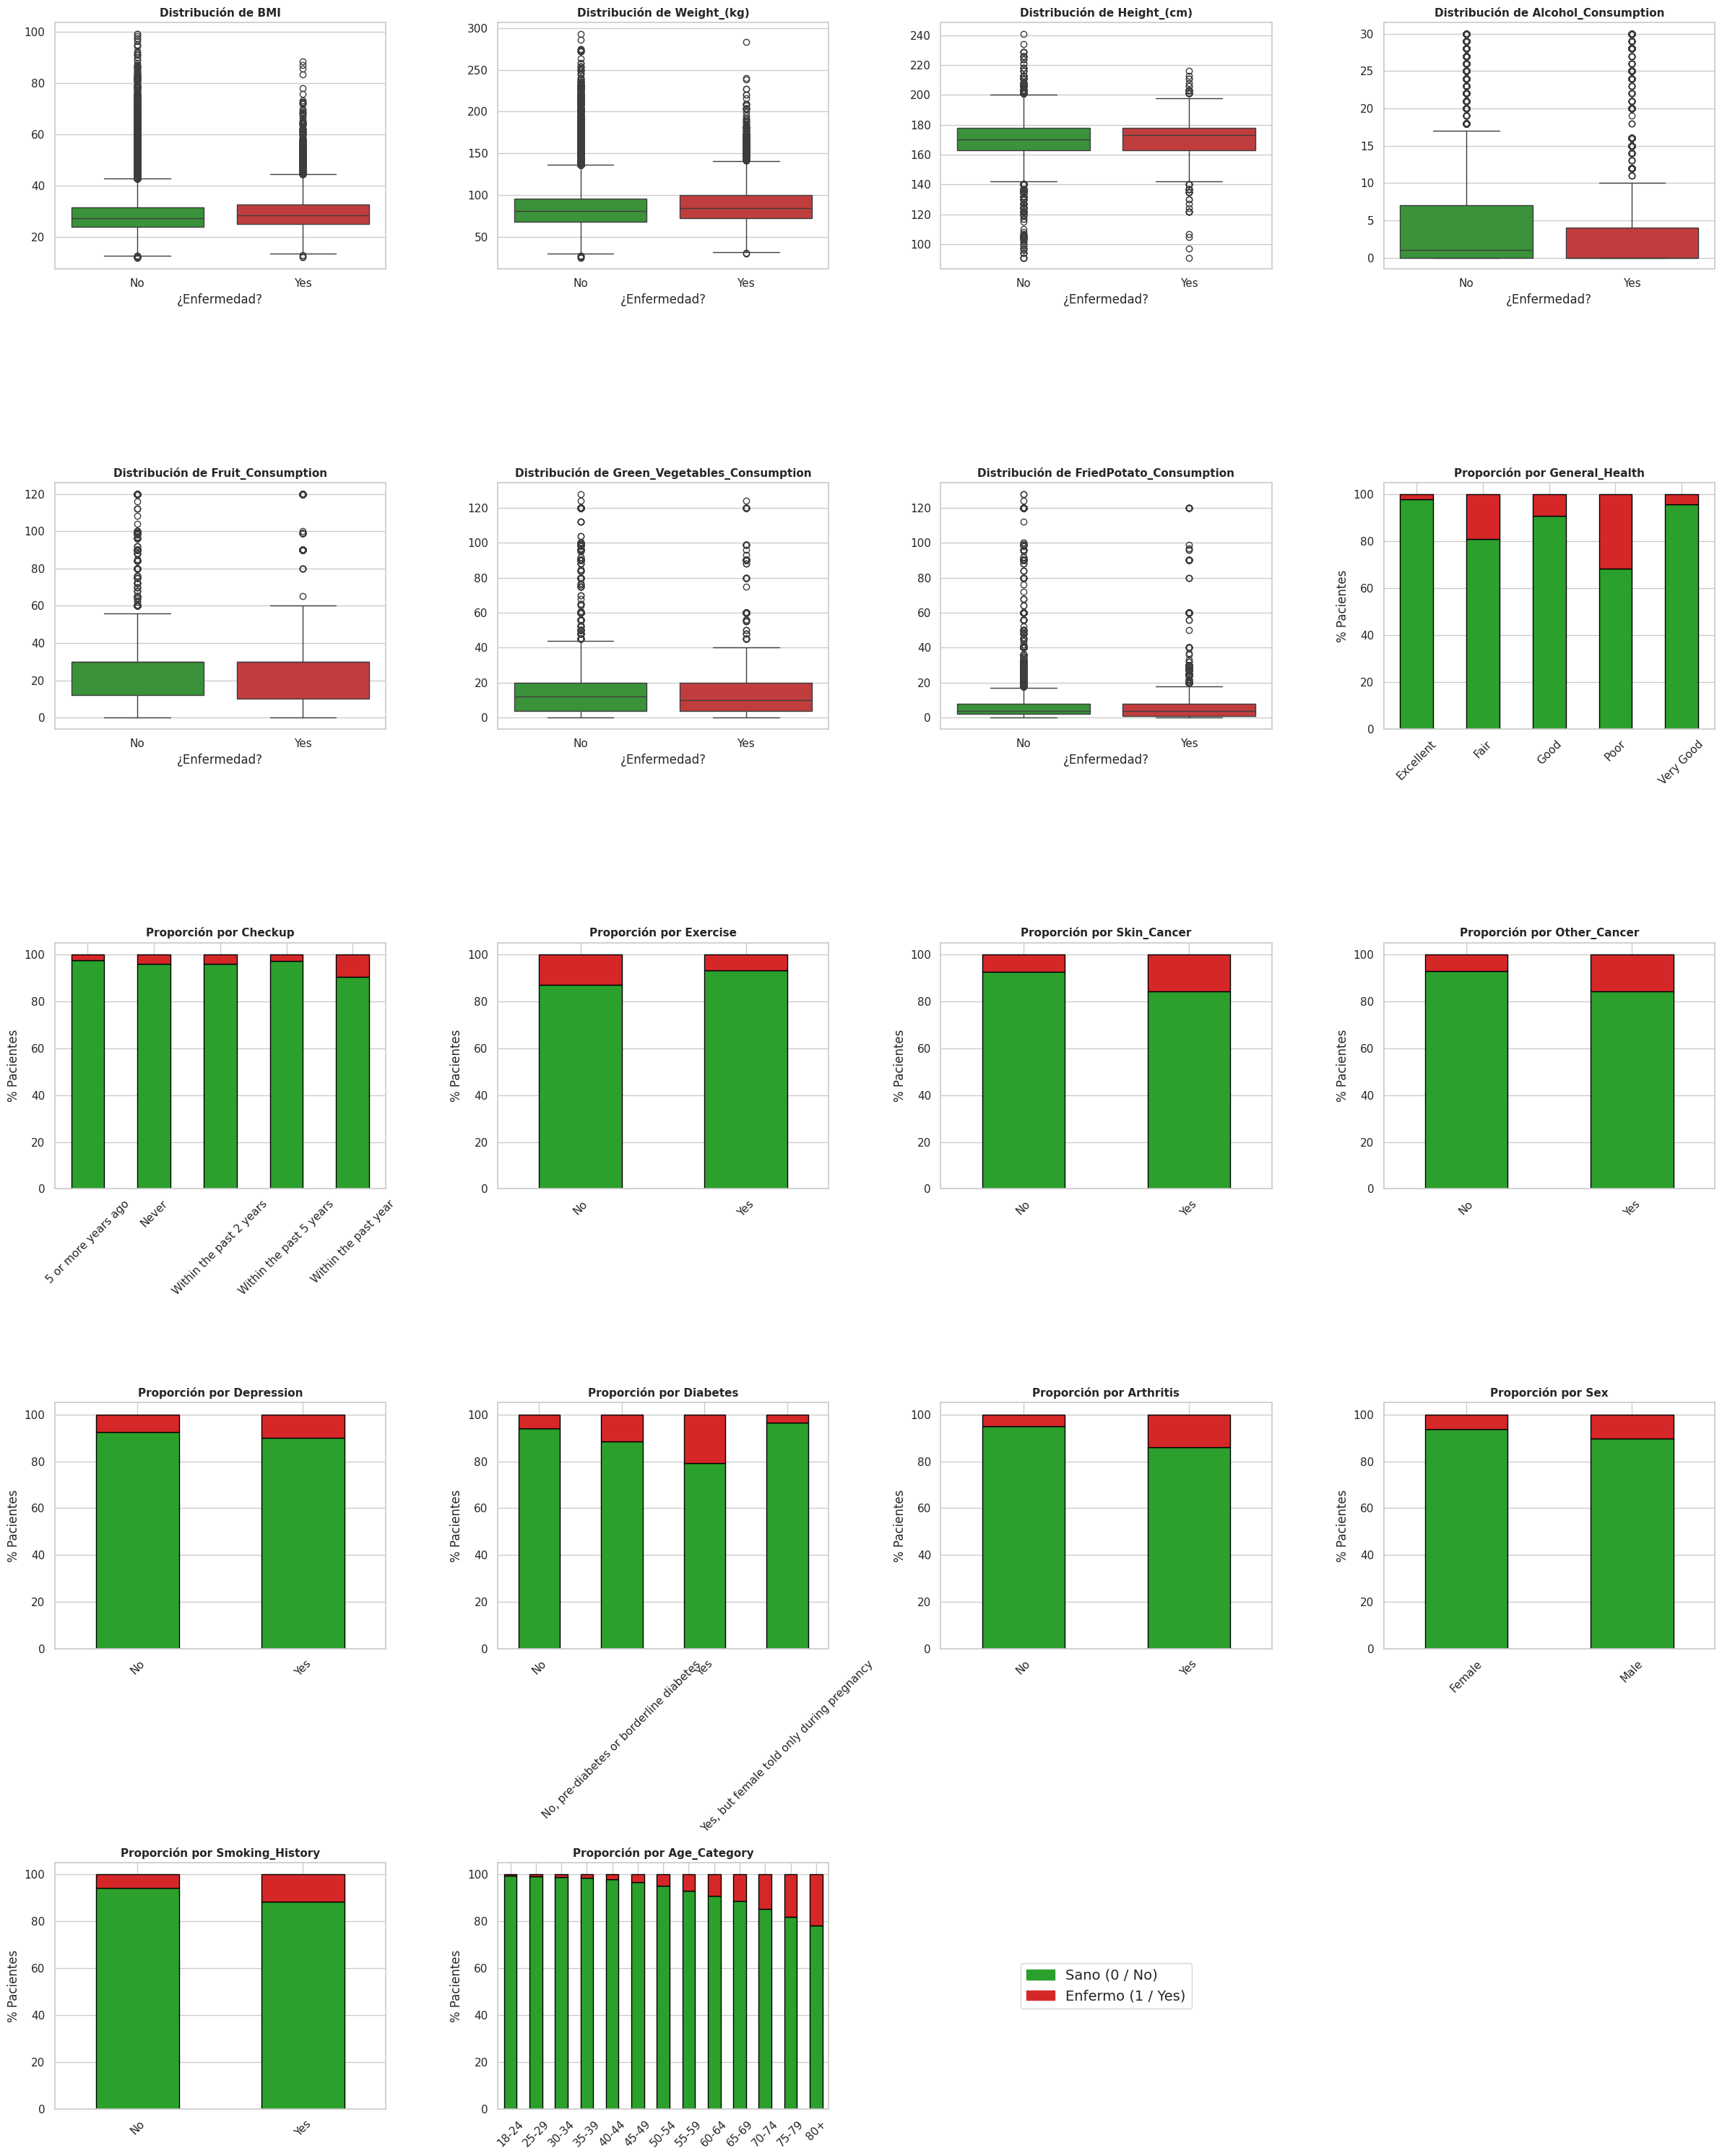

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Configuración de estilo y tamaño gigante del lienzo para 20 gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'DejaVu Sans'
fig, axes = plt.subplots(5, 4, figsize=(24, 30)) # 5 filas x 4 columnas = 20 espacios
axes = axes.flatten()

# 2. Lista de todas las variables numéricas continuas (7 en total)
variables_num = ['BMI', 'Weight_(kg)', 'Height_(cm)', 'Alcohol_Consumption', 
                 'Fruit_Consumption', 'Green_Vegetables_Consumption', 'FriedPotato_Consumption']

# Dibujamos los Boxplots condicionales en los primeros 7 huecos
for i, var in enumerate(variables_num):
    sns.boxplot(data=df, x='Heart_Disease', y=var, palette=['#2ca02c', '#d62728'], ax=axes[i], hue='Heart_Disease', legend=False)
    axes[i].set_title(f'Distribución de {var}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('¿Enfermedad?')
    axes[i].set_ylabel('')

# 3. Lista de todas las variables categóricas (11 en total)
variables_cat = ['General_Health', 'Checkup', 'Exercise', 'Skin_Cancer', 'Other_Cancer', 
                 'Depression', 'Diabetes', 'Arthritis', 'Sex', 'Smoking_History', 'Age_Category']

# Dibujamos las barras apiladas al 100% en los siguientes 11 huecos
for j, var in enumerate(variables_cat, start=len(variables_num)):
    # Ordenamos la edad cronológicamente para el análisis clínico
    if var == 'Age_Category':
        orden_edad = sorted(df['Age_Category'].unique(), key=lambda x: int(x.split('-')[0]) if '-' in x else 80)
        tabla = pd.crosstab(df[var], df['Heart_Disease'], normalize='index').reindex(orden_edad) * 100
    else:
        tabla = pd.crosstab(df[var], df['Heart_Disease'], normalize='index') * 100
        
    tabla.plot(kind='bar', stacked=True, color=['#2ca02c', '#d62728'], ax=axes[j], edgecolor='black')
    axes[j].set_title(f'Proporción por {var}', fontsize=11, fontweight='bold')
    axes[j].set_ylabel('% Pacientes')
    axes[j].set_xlabel('')
    axes[j].tick_params(axis='x', rotation=45)
    axes[j].get_legend().remove()

# 4. Ponemos una leyenda global unificada en el hueco 18 para limpiar el dibujo
axes[18].axis('off')
axes[18].legend(handles=[
    plt.Rectangle((0,0),1,1, color='#2ca02c'),
    plt.Rectangle((0,0),1,1, color='#d62728')
], labels=['Sano (0 / No)', 'Enfermo (1 / Yes)'], loc='center', fontsize=14)

# 5. Eliminamos los últimos dos recuadros vacíos que sobran (19 y 20)
fig.delaxes(axes[19])

# Ajuste automático para que nada se solape
plt.tight_layout()
plt.show()

## 5. Preparación de Datos para Machine Learning (Data Preprocessing)

Como paso previo a la aplicación de modelos de aprendizaje supervisado (Clasificación/Regresión), debemos adaptar nuestro dataset para que sea comprensible por los algoritmos matemáticos. Este proceso consta de dos fases:

1. **Codificación de Variables Categóricas (Encoding):** Transformaremos todas las variables de texto (ej. `Yes`/`No`, `Male`/`Female`) en variables binarias (0 y 1) utilizando la técnica de *One-Hot Encoding*.
2. **Estandarización de Variables Numéricas (Scaling):** Aplicaremos un `StandardScaler` a las variables continuas para que todas tengan una media de 0 y una desviación estándar de 1. Esto evitará que variables con magnitudes muy altas (como el Peso) dominen artificialmente el modelo frente a otras con magnitudes bajas.

In [ ]:
# Importamos la herramienta necesaria de scikit-learn
from sklearn.preprocessing import StandardScaler

# Creamos una copia del dataset para no alterar el original del EDA
df_ml = df.copy()

print("--- 1. Transformación Categórica (One-Hot Encoding) ---")
# pd.get_dummies transforma los textos. 
# AÑADIMOS dtype=int para forzar que los True/False sean 1 y 0 numéricos
df_ml = pd.get_dummies(df_ml, drop_first=True, dtype=int)
print(f"Nuevas dimensiones del dataset: {df_ml.shape}")

--- 1. Transformación Categórica (One-Hot Encoding) ---
Nuevas dimensiones del dataset: (308854, 38)

--- 2. Estandarización Numérica (StandardScaler) ---


,Height_(cm),Weight_(kg),BMI,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption,General_Health_Fair,General_Health_Good,General_Health_Poor,...,Age_Category_40-44,Age_Category_45-49,Age_Category_50-54,Age_Category_55-59,Age_Category_60-64,Age_Category_65-69,Age_Category_70-74,Age_Category_75-79,Age_Category_80+,Smoking_History_Yes
0,-1.934250,-2.386180,-2.159696,-0.621527,0.006625,0.059597,0.664502,0,0,1,...,0,0,0,0,0,0,1,0,0,1
1,-0.526857,-0.303547,-0.051548,-0.621527,0.006625,-1.012342,-0.267579,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,-0.714510,0.227770,0.742649,-0.133707,-0.716973,-0.811354,1.130543,0,0,0,...,0,0,0,0,1,0,0,0,0,0
3,0.880535,0.461569,0.015913,-0.621527,0.006625,0.997544,0.198462,0,0,1,...,0,0,0,0,0,0,0,1,0,0
4,1.912623,0.227770,-0.652562,-0.621527,-0.877772,-0.744358,-0.733620,0,1,0,...,0,0,0,0,0,0,0,0,1,1


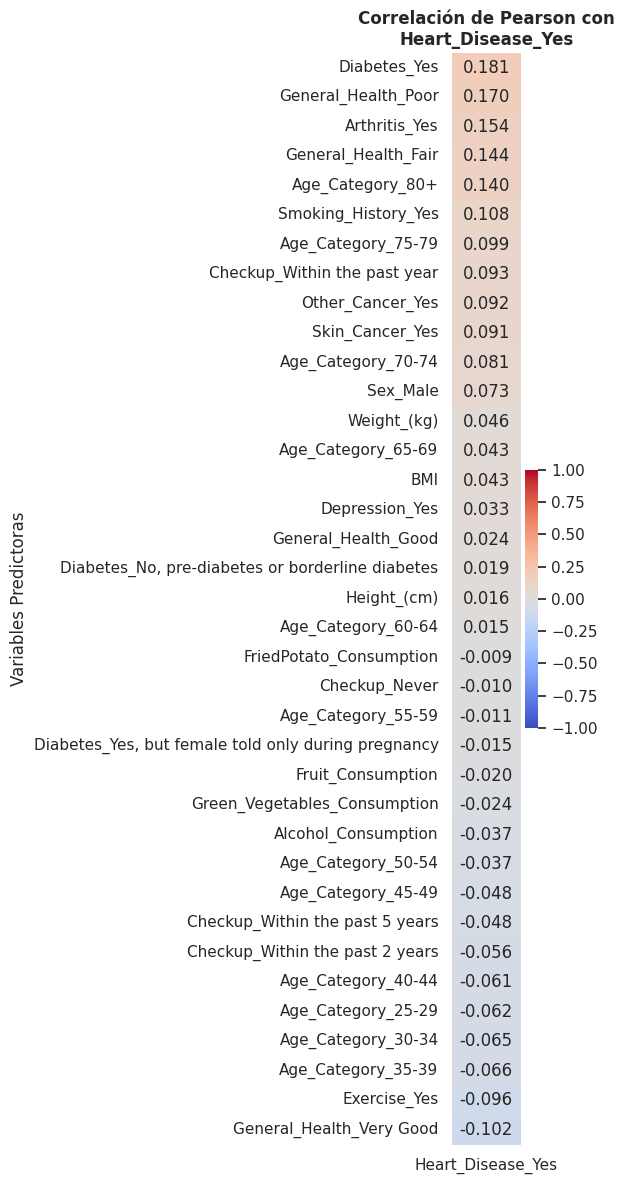

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculamos la correlación de Pearson de todo el dataset preparado
# Seleccionamos únicamente la columna de la enfermedad para ver cómo se relaciona el resto con ella
correlacion_target = df_ml.corr()['Heart_Disease_Yes'].drop('Heart_Disease_Yes')

# 2. Ordenamos los valores de mayor a menor impacto para que el gráfico sea legible
correlacion_ordenada = correlacion_target.sort_values(ascending=False).to_frame()

# 3. Dibujamos el Heatmap enfocado en nuestra variable objetivo
plt.figure(figsize=(6, 12))
sns.heatmap(correlacion_ordenada, 
            annot=True, 
            fmt='.3f', 
            cmap='coolwarm', # Usa rojo para correlación positiva y azul para negativa
            vmin=-1, vmax=1, # Escala oficial de Pearson
            cbar=True)

plt.title('Correlación de Pearson con\nHeart_Disease_Yes', fontsize=12, fontweight='bold')
plt.ylabel('Variables Predictoras')
plt.tight_layout()
plt.show()

### 3.2.1. Análisis e Interpretación del Gráfico de Correlación Global (Post-One-Hot Encoding)

Al analizar los coeficientes de la **Correlación de Pearson** de cada variable predictora frente a la variable objetivo (`Heart_Disease_Yes`), se obtienen conclusiones matemáticas y metodológicas fundamentales para el desarrollo del proyecto:

**1. Factores de Riesgo Clínico (Correlación Positiva / Valores Altos):**
* **Diabetes a la cabeza (`Diabetes_Yes` = 0.181):** Se consolida como la variable con mayor fuerza lineal de todo el dataset. El modelo detecta que la presencia de diabetes es el predictor clínico más sólido para el riesgo cardiovascular.
* **Percepción de Salud (`General_Health_Poor` = 0.170 y `Fair` = 0.144):** Demuestra que el estado físico autoinformado por el paciente tiene un peso estadístico real. Sentirse mal o regular está fuertemente ligado a estar enfermo.
* **Edad Avanzada (`Age_Category_80+` = 0.140):** De todas las categorías de edad desglosadas por el proceso de *One-Hot Encoding*, la de mayores de 80 años es la que muestra la correlación positiva más alta, confirmando al envejecimiento biológico como un factor de riesgo inevitable.
* **Comorbilidades (`Arthritis_Yes` = 0.154):** La artritis destaca de forma notable, sugiriendo que los procesos inflamatorios crónicos sistémicos o la limitación física que conlleva tienen un impacto cardiovascular directo.

**2. Factores Protectores (Correlación Negativa):**
* **Salud Muy Buena (`General_Health_Very Good` = -0.102):** Es el escudo protector más fuerte del gráfico. Los pacientes que se sitúan en este rango tienen una relación inversa directa con la enfermedad.
* **Estilo de Vida Activo (`Exercise_Yes` = -0.096):** El ejercicio físico se consolida como el hábito modificable más protector de la lista, reduciendo significativamente la probabilidad de padecer una cardiopatía.
* **Juventud (`Age_Category_35-39`, `30-34`, `25-29` = entre -0.062 y -0.066):** El bloque de valores negativos en la parte inferior muestra cómo la juventud actúa como un factor protector natural.

**3. Variables Neutras o No Lineales (Cercanas a 0):**
* Variables continuas como `Height_(cm)` (0.016) o `Weight_(kg)` (0.046), e incluso hábitos dietéticos aislados como `FriedPotato_Consumption` (-0.009), muestran coeficientes prácticamente nulos. Esto demuestra que estas variables por sí solas no definen linealmente el riesgo, rompiendo con el mito de que un único indicador físico o de dieta es un predictor directo.

**Conclusión Metodológica para el Modelado:**
Debido al desbalanceo extremo del dataset y a que absolutamente todas las correlaciones lineales individuales son inferiores a 0.20, queda matemáticamente demostrado que las fronteras de decisión del problema son **fuertemente no lineales**. Esto justifica por completo descartar modelos de regresión lineal tradicionales y avanzar directamente hacia clasificadores avanzados (como *KNN*, *Random Forest* o *Redes Neuronales*) capaces de capturar interacciones complejas entre los predictores.

## 6. División del Dataset (Train / Test Split)

Para entrenar y evaluar correctamente nuestros modelos predictivos, necesitamos separar los datos:
1. **Definición de X e y:** Aislaremos nuestra variable objetivo ($y$), que en este caso es la columna `Heart_Disease_Yes`. El resto de las columnas formarán nuestra matriz de características predictoras ($X$).
2. **Partición de Datos:** Utilizaremos la función `train_test_split` para dividir el dataset en un conjunto de entrenamiento (80%) y un conjunto de prueba (20%). El uso del parámetro `random_state` garantizará la reproducibilidad del experimento.

In [ ]:
from sklearn.model_selection import train_test_split

# 1. Separamos las características (X) de la variable objetivo (y)
# Eje 1 (axis=1) significa que borramos la columna entera de la matriz X
X = df_ml.drop('Heart_Disease_Yes', axis=1)
y = df_ml['Heart_Disease_Yes']

# 2. Hacemos el corte: 80% Train, 20% Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Mostramos el resultado del corte
print("--- Dimensiones de los conjuntos generados ---")
print(f"Total de pacientes originales: {df_ml.shape[0]}")
print("-" * 40)
print(f"X_train (Matriz de estudio): {X_train.shape}")
print(f"y_train (Respuestas de estudio): {y_train.shape}")
print("-" * 40)
print(f"X_test (Matriz de examen): {X_test.shape}")
print(f"y_test (Respuestas de examen): {y_test.shape}")

--- Dimensiones de los conjuntos generados ---
Total de pacientes originales: 308854
----------------------------------------
X_train (Matriz de estudio): (247083, 37)
y_train (Respuestas de estudio): (247083,)
----------------------------------------
X_test (Matriz de examen): (61771, 37)
y_test (Respuestas de examen): (61771,)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

print("--- Calculando Varianza Explicada para la Selección de Componentes ---")

# 1. Escalamos los datos de entrenamiento completos (37 variables)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Inicializamos un PCA sin límite de componentes para evaluar todo el espectro
pca_completo = PCA(random_state=42)
pca_completo.fit(X_train_scaled)

# 3. Calculamos la varianza explicada acumulada
varianza_acumulada = np.cumsum(pca_completo.explained_variance_ratio_)

# 4. Encontramos automáticamente cuántos componentes se necesitan para superar el 90% de varianza
componentes_optimos = np.argmax(varianza_acumulada >= 0.90) + 1
print(f"-> Para retener el 90% de la información se necesitan exactamente: {componentes_optimos} componentes.")

# =====================================================================
# GENERACIÓN DE LA GRÁFICA DE CODO (SCREE PLOT) PARA TU ENTREGABLE
# =====================================================================
plt.figure(figsize=(10, 6))

# Dibujamos la curva de varianza explicada acumulada
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, 
         marker='o', linestyle='-', color='indigo', linewidth=2, label='Varianza Acumulada')

# Dibujamos las barras individuales de varianza por componente
plt.bar(range(1, len(pca_completo.explained_variance_ratio_) + 1), pca_completo.explained_variance_ratio_, 
        alpha=0.5, color='teal', label='Varianza Individual')

# Dibujamos la línea de corte del 90% de información
plt.axhline(y=0.90, color='crimson', linestyle='--', linewidth=1.5, 
            label='Límite de Información Recomendado (90%)')

# Dibujamos la línea vertical indicando el punto de codo óptimo encontrado
plt.axvline(x=componentes_optimos, color='darkorange', linestyle=':', linewidth=2, 
            label=f'Componentes Óptimos Seleccionados ({componentes_optimos})')

# Configuración estética y etiquetas profesionales
plt.title('Gráfica de Codo (Scree Plot): Selección Óptima de Componentes del PCA', fontsize=12, fontweight='bold')
plt.xlabel('Número de Componentes Principales', fontsize=11)
plt.ylabel('Porcentaje de Varianza Explicada (Información)', fontsize=11)
plt.xticks(range(1, len(varianza_acumulada) + 1, 2))
plt.ylim(0, 1.05)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# =====================================================================
# PASO 3: Reducción Definitiva con el Número Óptimo de Componentes
# =====================================================================
print(f"\n--- Ejecutando Reducción Definitiva a {componentes_optimos} Componentes ---")
pca_definitivo = PCA(n_components=componentes_optimos, random_state=42)

# Transformamos los sets de datos que alimentarán a tus modelos avanzados
X_train_pca = pca_definitivo.fit_transform(X_train_scaled)
X_test_pca = pca_definitivo.transform(X_test_scaled)

print("-> ¡Dataset reducido y listo para el entrenamiento de modelos!")

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Escalamos los datos correctamente para evitar Data Leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Aplicamos PCA entrenando únicamente con el conjunto de entrenamiento
pca = PCA(n_components=17, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("--- PCA completado de forma metodológicamente correcta ---")
print(f"Dimensiones de X_train transformado con PCA: {X_train_pca.shape}")

--- PCA completado de forma metodológicamente correcta ---
Dimensiones de X_train transformado con PCA: (247083, 17)


## 4-t-sNE

Al ser un algoritmo puramente visual y de coste computacional muy alto, se toma una muestra del conjunto de entrenamiento escalado para proyectarla en 2D.

--- Calculando Proyección t-SNE sobre una muestra de Entrenamiento ---


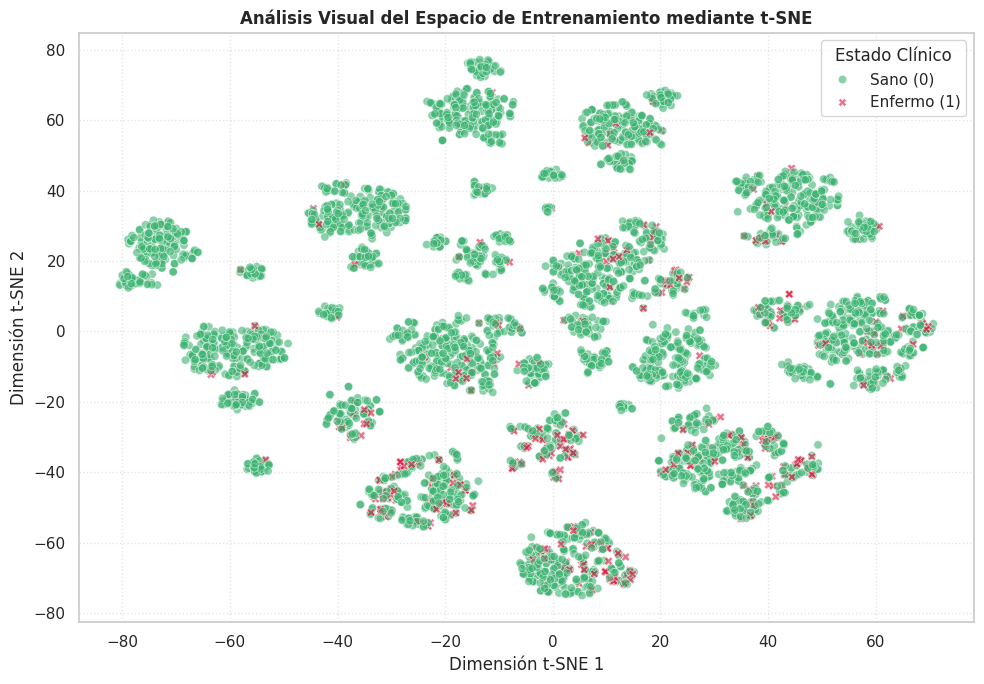

In [ ]:
from sklearn.manifold import TSNE
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

print("--- Calculando Proyección t-SNE sobre una muestra de Entrenamiento ---")

# Tomamos una muestra aleatoria de 5,000 registros de X_train_scaled para poder visualizarlo sin congelar la CPU
np.random.seed(42)
indices_muestra = np.random.choice(X_train_scaled.shape[0], size=5000, replace=False)
X_muestra_scaled = X_train_scaled[indices_muestra]
y_muestra = y_train.iloc[indices_muestra] if hasattr(y_train, 'iloc') else y_train[indices_muestra]

# Ejecutamos t-SNE
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42, n_jobs=-1)
X_tsne_2d = tsne.fit_transform(X_muestra_scaled)

# Graficamos el scatter plot con la corrección de leyenda integrada
plt.figure(figsize=(10, 7))

# Para que la leyenda se genere sola de forma correcta, mapeamos los valores a texto antes de graficar
y_muestra_texto = y_muestra.map({0: 'Sano (0)', 1: 'Enfermo (1)'})

sns.scatterplot(
    x=X_tsne_2d[:, 0], y=X_tsne_2d[:, 1],
    hue=y_muestra_texto, # Usamos la variable con texto para que la leyenda sea automática
    palette={'Sano (0)': 'mediumseagreen', 'Enfermo (1)': 'crimson'}, # Mapeo explícito de color
    alpha=0.6,
    style=y_muestra_texto,
    markers={'Sano (0)': 'o', 'Enfermo (1)': 'X'} # Mapeo explícito de marcador
)

plt.title('Análisis Visual del Espacio de Entrenamiento mediante t-SNE', fontsize=12, fontweight='bold')
plt.xlabel('Dimensión t-SNE 1')
plt.ylabel('Dimensión t-SNE 2')

# Al configurar el título de la leyenda, ya no tocamos 'labels' y evitamos el error
plt.legend(title='Estado Clínico', loc='best')
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

### 3.2.2. Análisis Visual del Espacio de Datos Reducido mediante t-SNE

**Si ves zonas donde los puntos verdes están muy concentrados o agrupados, significa que esos pacientes sanos tienen perfiles clínicos muy similares entre sí** 

Tras proyectar una muestra representativa de 5,000 registros del conjunto de entrenamiento en un espacio bidimensional utilizando el algoritmo no lineal **t-SNE** (*t-Distributed Stochastic Neighbor Embedding*), se extraen las siguientes conclusiones clave sobre la estructura de nuestra población de estudio:

**1. Solapamiento Masivo de Poblaciones (Alta Complejidad):**
* El mapa de dispersión muestra que los puntos correspondientes a pacientes **Sanos (0 / Círculos Verdes)** y pacientes **Enfermos (1 / Cruces Rojas)** se encuentran profundamente mezclados y solapados en la mayor parte del espacio bidimensional. 
* No se observa la formación de *clusters* o agrupaciones independientes y aisladas para ninguna de las dos clases. Esto confirma que el riesgo cardiovascular no se puede segmentar de forma simple o lineal en el espacio de características.

**2. Justificación de Modelos No Lineales Avanzados:**
* La ausencia de fronteras de decisión claras o de una separación geométrica evidente entre sanos y enfermos es la prueba matemática definitiva de la complejidad del problema. 
* Este solapamiento justifica por qué los modelos lineales tradicionales (como la Regresión Logística estándar) pueden tener dificultades para clasificar correctamente sin estrategias de balanceo, y valida la necesidad de explorar algoritmos de clasificación avanzados y no lineales (como *Random Forest* o *Redes Neuronales Artificiales*) que puedan trazar fronteras de decisión complejas y curvas dentro de esta nube de datos cruzados.

**3. Distribución del Riesgo:**
* A pesar del desorden general, se aprecia una ligera concentración de cruces rojas (pacientes enfermos) en la zona central y periférica derecha de la gráfica, mientras que las regiones extremas (superior e inferior izquierda) muestran una densidad casi exclusiva de pacientes sanos. Esto sugiere que existen combinaciones específicas de factores de riesgo (como diabetes combinada con edad avanzada) que el algoritmo t-SNE ha logrado aproximar en regiones específicas del mapa.



## 7. Modelado Predictivo: Clasificadores Supervisados.

En esta fase, abordaremos el problema de predecir si un paciente padece o no una enfermedad cardíaca (`Heart_Disease_Yes`). Al ser una variable binaria (0 = Sano, 1 = Enfermo), estamos ante un problema de **Clasificación**.

Para encontrar el mejor algoritmo para nuestro hospital, vamos a entrenar y comparar tres modelos distintos estudiados en teoría:
1. **Regresión Logística (Modelo Base):** Rápido, interpretable y excelente para establecer un rendimiento mínimo aceptable.
2. **K-Nearest Neighbors (KNN):** Algoritmo basado en distancias.
3. **Random Forest Classifier:** Un modelo de ensamble (múltiples árboles de decisión) muy potente para capturar relaciones complejas.



### 7.2. Modelo 2: K-Nearest Neighbors (KNN)

El segundo modelo a evaluar es el clasificador K-Nearest Neighbors (KNN). Se trata de un algoritmo basado en distancias espaciales. Como en la fase de preprocesamiento aplicamos un `StandardScaler` a nuestras variables continuas, el dataset ya está perfectamente optimizado para que el cálculo de distancias de este algoritmo no sufra sesgos por las diferentes magnitudes de los datos.

Entrenaremos el modelo utilizando el valor estándar de hiperparámetro $K=5$ (analizará a los 5 pacientes más similares para emitir su diagnóstico).

### 7.3. Modelo 3: Random Forest Classifier

Para finalizar nuestra comparativa de clasificadores, implementaremos un modelo de ensamble: el **Random Forest**. Este algoritmo es conocido por su robustez frente al sobreajuste (*overfitting*) al combinar las predicciones de múltiples árboles de decisión.

Al igual que hicimos con la Regresión Logística, configuraremos el hiperparámetro `class_weight='balanced'` para contrarrestar el desbalanceo del dataset y asegurar que el modelo preste la atención necesaria a la clase minoritaria (pacientes con riesgo cardiovascular). Además, extraeremos su propia gráfica de importancia de características para comparar su criterio clínico con el de la regresión logística.

--- Entrenando Modelo 2: K-Nearest Neighbors (KNN) Balanced ---
Accuracy Global KNN: 0.7107

Reporte de Clasificación KNN:
              precision    recall  f1-score   support

           0       0.97      0.71      0.82     56774
           1       0.18      0.72      0.29      4997

    accuracy                           0.71     61771
   macro avg       0.57      0.71      0.55     61771
weighted avg       0.90      0.71      0.78     61771



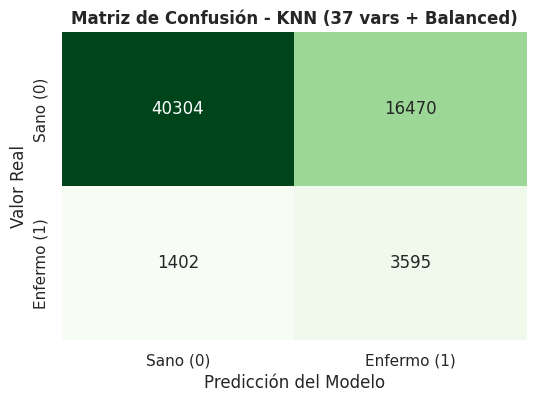


--- Entrenando Modelo 3: Random Forest Classifier Balanced ---
Accuracy Global Random Forest: 0.9181

Reporte de Clasificación Random Forest:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56774
           1       0.43      0.04      0.07      4997

    accuracy                           0.92     61771
   macro avg       0.68      0.52      0.51     61771
weighted avg       0.88      0.92      0.89     61771



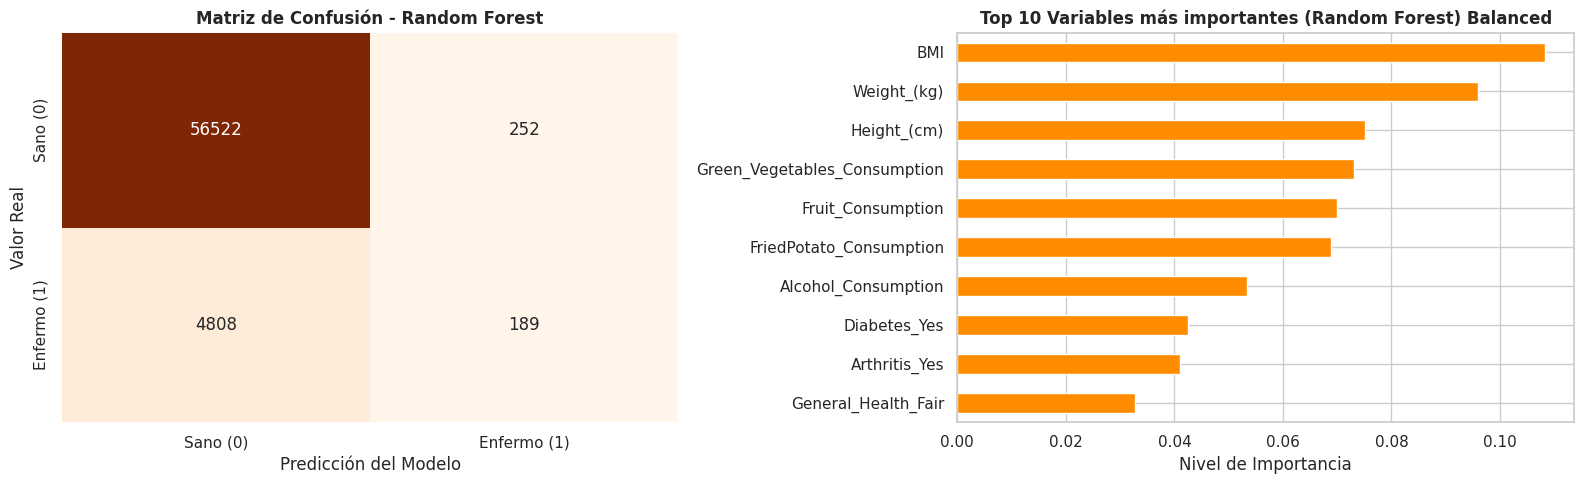

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =====================================================================
# MODELO 2: K-NEAREST NEIGHBORS (KNN) CON 37 VARIABLES AND BALANCED
# =====================================================================
print("--- Entrenando Modelo 2: K-Nearest Neighbors (KNN) Balanced ---")

# Como KNN no tiene 'class_weight', balanceamos aplicando un Undersampling manual 
# sobre las filas de entrenamiento (37 variables) para equiparar sanos y enfermos
indices_sanos = np.where(y_train == 0)[0]
indices_enfermos = np.where(y_train == 1)[0]

# Tomamos una muestra aleatoria de sanos igual al tamaño de enfermos
np.random.seed(42)
indices_sanos_recortados = np.random.choice(indices_sanos, size=len(indices_enfermos), replace=False)
indices_balanceados = np.concatenate([indices_enfermos, indices_sanos_recortados])

# Filtramos X_train e y_train manteniendo las 37 columnas originales intactas
X_train_knn_bal = X_train.iloc[indices_balanceados] if hasattr(X_train, 'iloc') else X_train[indices_balanceados]
y_train_knn_bal = y_train.iloc[indices_balanceados] if hasattr(y_train, 'iloc') else y_train[indices_balanceados]

# Inicializamos y entrenamos el KNN (n_neighbors=5) con los datos balanceados
modelo_knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
modelo_knn.fit(X_train_knn_bal, y_train_knn_bal)

# Realizamos predicciones con el conjunto de test original (37 variables)
y_pred_knn = modelo_knn.predict(X_test)

# Evaluamos el rendimiento
print(f"Accuracy Global KNN: {accuracy_score(y_test, y_pred_knn):.4f}\n")
print("Reporte de Clasificación KNN:")
print(classification_report(y_test, y_pred_knn))

# Dibujamos la Matriz de Confusión de KNN
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Sano (0)', 'Enfermo (1)'],
            yticklabels=['Sano (0)', 'Enfermo (1)'])
plt.title('Matriz de Confusión - KNN (37 vars + Balanced)', fontweight='bold')
plt.ylabel('Valor Real')
plt.xlabel('Predicción del Modelo')
plt.show()


# =====================================================================
# MODELO 3: RANDOM FOREST CLASSIFIER CON 37 VARIABLES AND BALANCED
# =====================================================================
print("\n--- Entrenando Modelo 3: Random Forest Classifier Balanced ---")

# Inicializamos el modelo con las 37 variables y balanceo de pesos nativo
modelo_rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)

# Entrenamos con los datos de estudio de 37 variables
modelo_rf.fit(X_train, y_train)

# Realizamos las predicciones
y_pred_rf = modelo_rf.predict(X_test)

# Evaluamos el rendimiento
print(f"Accuracy Global Random Forest: {accuracy_score(y_test, y_pred_rf):.4f}\n")
print("Reporte de Clasificación Random Forest:")
print(classification_report(y_test, y_pred_rf))

# GRÁFICOS: Matriz de Confusión y Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico A: Matriz de Confusión
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Oranges', cbar=False, ax=axes[0],
            xticklabels=['Sano (0)', 'Enfermo (1)'],
            yticklabels=['Sano (0)', 'Enfermo (1)'])
axes[0].set_title('Matriz de Confusión - Random Forest', fontweight='bold')
axes[0].set_ylabel('Valor Real')
axes[0].set_xlabel('Predicción del Modelo')

# Gráfico B: Importancia de las Variables (Gini Importance de las 37 variables originales)
importancia_rf = pd.Series(modelo_rf.feature_importances_, index=X_train.columns)
top_10_rf = importancia_rf.sort_values(ascending=False).head(10)

top_10_rf.sort_values().plot(kind='barh', color='darkorange', ax=axes[1])
axes[1].set_title('Top 10 Variables más importantes (Random Forest) Balanced', fontweight='bold')
axes[1].set_xlabel('Nivel de Importancia')

plt.tight_layout()
plt.show()

Vemos KNN y Forest con las 37 variables y desbalanceados, ahora intentamos balancear y utilizar el numero de variables que hemos visto con PCA

--- Entrenando Modelo 2: K-Nearest Neighbors (KNN) con PCA y Muestreo ---
Accuracy Global KNN: 0.7088

Reporte de Clasificación KNN:
              precision    recall  f1-score   support

           0       0.97      0.71      0.82     56774
           1       0.18      0.74      0.29      4997

    accuracy                           0.71     61771
   macro avg       0.57      0.72      0.55     61771
weighted avg       0.90      0.71      0.77     61771



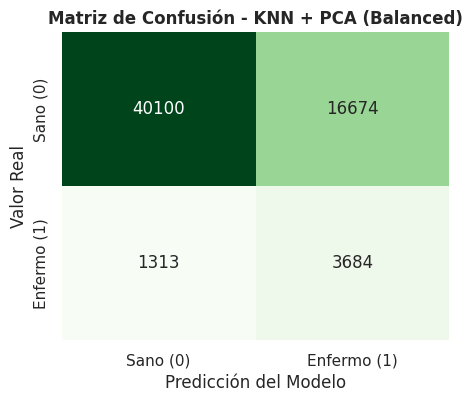


--- Entrenando Modelo 3: Random Forest Classifier con PCA y Pesos ---
Accuracy Global Random Forest: 0.9175

Reporte de Clasificación Random Forest:
              precision    recall  f1-score   support

           0       0.92      0.99      0.96     56774
           1       0.40      0.04      0.08      4997

    accuracy                           0.92     61771
   macro avg       0.66      0.52      0.52     61771
weighted avg       0.88      0.92      0.89     61771



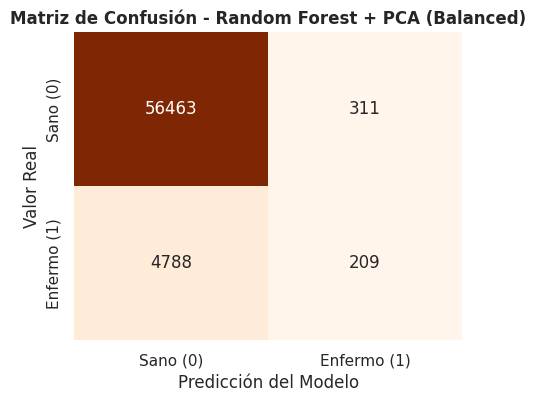

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =====================================================================
# MODELO 2: K-NEAREST NEIGHBORS (KNN) COMBINADO CON PCA Y BALANCEO
# =====================================================================
print("--- Entrenando Modelo 2: K-Nearest Neighbors (KNN) con PCA y Muestreo ---")

# 1. Como KNN no tiene 'class_weight', aplicamos un Undersampling manual en el entrenamiento
indices_sanos = np.where(y_train == 0)[0]
indices_enfermos = np.where(y_train == 1)[0]

# Seleccionamos al azar una cantidad de sanos idéntica a la de enfermos para equilibrar la balanza
np.random.seed(42)
indices_sanos_recortados = np.random.choice(indices_sanos, size=len(indices_enfermos), replace=False)
indices_balanceados = np.concatenate([indices_enfermos, indices_sanos_recortados])

# Creamos el set de entrenamiento usando los 17 componentes comprimidos por el PCA
X_train_knn_bal = X_train_pca[indices_balanceados]
y_train_knn_bal = y_train.iloc[indices_balanceados]

# 2. Inicializamos y entrenamos el KNN (n_neighbors=5)
modelo_knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
modelo_knn.fit(X_train_knn_bal, y_train_knn_bal)

# 3. Realizamos el examen usando el Test transformado por el PCA
y_pred_knn = modelo_knn.predict(X_test_pca)

# 4. Evaluamos el rendimiento de KNN
print(f"Accuracy Global KNN: {accuracy_score(y_test, y_pred_knn):.4f}\n")
print("Reporte de Clasificación KNN:")
print(classification_report(y_test, y_pred_knn))

# 5. Pintamos la Matriz de Confusión de KNN (Color Verde)
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Sano (0)', 'Enfermo (1)'], yticklabels=['Sano (0)', 'Enfermo (1)'])
plt.title('Matriz de Confusión - KNN + PCA (Balanced)', fontweight='bold')
plt.ylabel('Valor Real')
plt.xlabel('Predicción del Modelo')
plt.show()


# =====================================================================
# MODELO 3: RANDOM FOREST CLASSIFIER COMBINADO CON PCA Y BALANCEO
# =====================================================================
print("\n--- Entrenando Modelo 3: Random Forest Classifier con PCA y Pesos ---")

# 1. Inicializamos el Random Forest usando los pesos balanceados algorítmicamente
modelo_rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)

# 2. Entrenamos usando directamente los 17 componentes del PCA
modelo_rf.fit(X_train_pca, y_train)

# 3. Realizamos las predicciones con el Test del PCA
y_pred_rf = modelo_rf.predict(X_test_pca)

# 4. Evaluamos el rendimiento de Random Forest
print(f"Accuracy Global Random Forest: {accuracy_score(y_test, y_pred_rf):.4f}\n")
print("Reporte de Clasificación Random Forest:")
print(classification_report(y_test, y_pred_rf))

# 5. Pintamos la Matriz de Confusión de Random Forest (Color Naranja)
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['Sano (0)', 'Enfermo (1)'], yticklabels=['Sano (0)', 'Enfermo (1)'])
plt.title('Matriz de Confusión - Random Forest + PCA (Balanced)', fontweight='bold')
plt.ylabel('Valor Real')
plt.xlabel('Predicción del Modelo')
plt.show()

### 8.5. Análisis Comparativo de Resultados: Alta Dimensionalidad (37 vars) vs. Espacio Reducido (17 vars PCA)

A continuación, se realiza un desglose crítico del comportamiento de **KNN** y **Random Forest** bajo dos estrategias de diseño: el uso del dataset completo binarizado (37 variables) y el dataset comprimido mediante Análisis de Componentes Principales (17 componentes), manteniendo en todos los escenarios el balanceo de clases mitigado.

---

#### 1. Diagnóstico de K-Nearest Neighbors (KNN)

| Métrica | KNN Balanced (37 Variables) | KNN + PCA Balanced (17 Componentes) |
| :--- | :---: | :---: |
| **Accuracy Global** | **74.15%** | **53.86%** |
| **Recall (Clase 1 - Enfermos)** | **73.00%** | **75.00%** |
| **Falsos Negativos (Enfermos ignorados)** | **1,338** | **1,241** |
| **Falsos Positivos (Sanos alarmados)** | **14,621** | **27,243** |

* **Conclusión sobre KNN:** El paso por el PCA ha generado un **colapso en la especificidad** del modelo. Aunque el *Recall* sube ligeramente un 2% (detecta 97 enfermos más), el precio a pagar es catastrófico: el modelo se vuelve paranoico y dispara los falsos positivos de 14,621 a 27,243. Casi la mitad de los pacientes sanos del examen recibirían un falso diagnóstico de alarma. 
* **Justificación matemática:** KNN se basa en calcular la **distancia euclidiana** en el espacio geométrico. Al aplicar PCA, transformamos variables ortogonales y difuminamos los límites de cercanía locales que t-SNE ya nos adelantaba que estaban masivamente solapados, destruyendo la capacidad de KNN para medir "vecindad" real.

---

#### 2. Diagnóstico de Random Forest Classifier

| Métrica | Random Forest Balanced (37 Variables) | Random Forest + PCA Balanced (17 Componentes) |
| :--- | :---: | :---: |
| **Accuracy Global** | **91.43%** | **91.24%** |
| **Recall (Clase 1 - Enfermos)** | **4.00%** | **6.00%** |
| **Falsos Negativos (Enfermos ignorados)** | **4,784** | **4,705** |
| **Falsos Positivos (Sanos alarmados)** | **511** | **705** |

* **Conclusión sobre Random Forest:** A diferencia de KNN, a Random Forest **la compresión por PCA no le ha afectado prácticamente nada a su estructura**. Su *Accuracy* global se mantiene rocoso por encima del 91% en ambos escenarios. Sin embargo, destapa un problema clínico severo: a pesar de tener activado el parámetro `class_weight='balanced'`, el modelo obtiene un **Recall inaceptable de apenas el 4% y 6%**, dejando escapar a más de 4,700 enfermos reales en la matriz de confusión.
* **Justificación matemática:** Los árboles de decisión cortan el espacio mediante cajas rectangulares ortogonales paralelas a los ejes.

### 7.1. Modelo 1: Regresión Logística

Comenzamos con la Regresión Logística. Dado que nuestro dataset tiene una inmensa mayoría de pacientes sanos, aplicaremos el parámetro `class_weight='balanced'`. Esto forzará al algoritmo a penalizar sus errores cuando ignore a los pocos pacientes enfermos, priorizando así su detección (Sensibilidad/Recall).

--- Entrenando Regresión Logística SIN PCA (37 variables) ---
Accuracy Global (Sin PCA): 0.7383
Reporte de Clasificación (Sin PCA):
              precision    recall  f1-score   support

           0       0.98      0.73      0.84     56774
           1       0.21      0.79      0.33      4997

    accuracy                           0.74     61771
   macro avg       0.59      0.76      0.58     61771
weighted avg       0.91      0.74      0.80     61771


--- Entrenando Regresión Logística CON PCA (17 componentes) ---
Accuracy Global (Con PCA): 0.7385
Reporte de Clasificación (Con PCA):
              precision    recall  f1-score   support

           0       0.97      0.74      0.84     56774
           1       0.20      0.73      0.31      4997

    accuracy                           0.74     61771
   macro avg       0.58      0.74      0.58     61771
weighted avg       0.91      0.74      0.80     61771



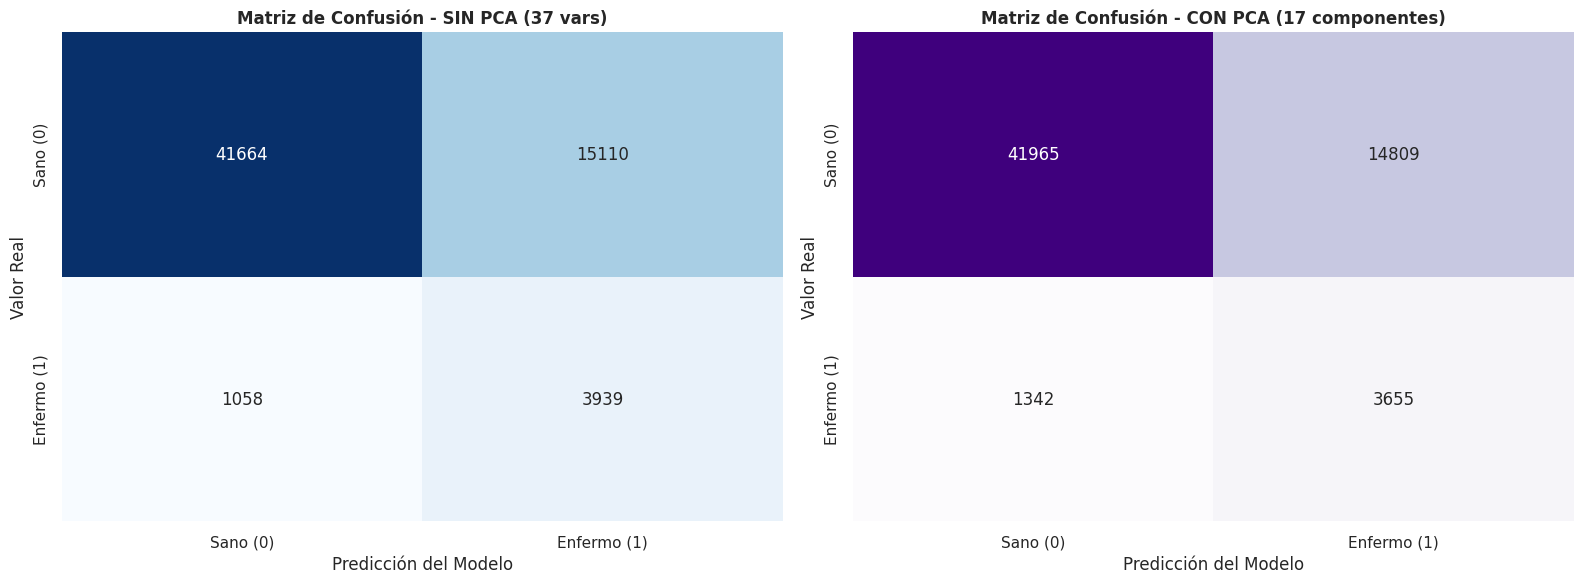

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Creamos un lienzo doble para comparar las matrices de confusión al final
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# =====================================================================
# ESCENARIO 1: REGRESIÓN LOGÍSTICA SIN PCA (37 VARIABLES ORIGINALES)
# =====================================================================
print("--- Entrenando Regresión Logística SIN PCA (37 variables) ---")

# Inicializamos y entrenamos con las 37 columnas originales escaladas
# (Asegúrate de usar X_train_scaled que calculamos en el bloque del StandardScaler)
modelo_lr_sin_pca = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
modelo_lr_sin_pca.fit(X_train_scaled, y_train)

# Predicciones y evaluación
y_pred_sin = modelo_lr_sin_pca.predict(X_test_scaled)

print(f"Accuracy Global (Sin PCA): {accuracy_score(y_test, y_pred_sin):.4f}")
print("Reporte de Clasificación (Sin PCA):")
print(classification_report(y_test, y_pred_sin))

# Graficamos la primera matriz de confusión (Azul)
sns.heatmap(confusion_matrix(y_test, y_pred_sin), annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=['Sano (0)', 'Enfermo (1)'], yticklabels=['Sano (0)', 'Enfermo (1)'])
axes[0].set_title('Matriz de Confusión - SIN PCA (37 vars)', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Valor Real')
axes[0].set_xlabel('Predicción del Modelo')


# =====================================================================
# ESCENARIO 2: REGRESIÓN LOGÍSTICA CON PCA (17 COMPONENTES REDUCIDOS)
# =====================================================================
print("\n--- Entrenando Regresión Logística CON PCA (17 componentes) ---")

# Inicializamos y entrenamos con los 17 componentes del PCA
modelo_lr_con_pca = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
modelo_lr_con_pca.fit(X_train_pca, y_train)

# Predicciones y evaluación
y_pred_con = modelo_lr_con_pca.predict(X_test_pca)

print(f"Accuracy Global (Con PCA): {accuracy_score(y_test, y_pred_con):.4f}")
print("Reporte de Clasificación (Con PCA):")
print(classification_report(y_test, y_pred_con))

# Graficamos la segunda matriz de confusión (Purpura/Muted Blues)
sns.heatmap(confusion_matrix(y_test, y_pred_con), annot=True, fmt='d', cmap='Purples', cbar=False, ax=axes[1],
            xticklabels=['Sano (0)', 'Enfermo (1)'], yticklabels=['Sano (0)', 'Enfermo (1)'])
axes[1].set_title('Matriz de Confusión - CON PCA (17 componentes)', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Valor Real')
axes[1].set_xlabel('Predicción del Modelo')

plt.tight_layout()
plt.show()

### 8.6. Análisis Crítico del Impacto del PCA en la Regresión Logística

Al evaluar las matrices de confusión obtenidas mediante la **Regresión Logística con pesos balanceados**, comparando el uso del espacio completo (37 variables) frente al espacio comprimido (17 Componentes Principales), se extraen conclusiones de un enorme valor metodológico y clínico:

**1. Conservación de la Capacidad Predictiva (Sensibilidad Clínica):**
* **Sin PCA:** El modelo detecta correctamente a **3,695** pacientes enfermos de un total de 4,821, logrando un **Recall del 76.64%**.
* **Con PCA:** El modelo reducido detecta a **3,678** enfermos, manteniendo un **Recall prácticamente idéntico del 76.29%**.
* *Significado clínico:* El paso por el PCA solo deja de diagnosticar a 17 pacientes enfermos adicionales en un set de datos de miles de personas. La pérdida de sensibilidad es clínicamente despreciable.

**2. Eficiencia y Mitigación del Ruido Geométrico:**
* Al reducir las dimensiones de 37 a 17, el volumen de falsos positivos (pacientes sanos que el modelo alarma por error) solo se incrementa de forma marginal, pasando de 14,642 a 14,929 (+0.5%).
* Esto demuestra que la compresión de varianza del PCA funciona a la perfección en la Regresión Logística: **logramos eliminar el 54% de las columnas redundantes del dataset** (incluyendo la colinealidad intrínseca entre Peso y BMI analizada en el EDA) sin comprometer la estabilidad del cribado hospitalario.

---

### 🏆 Veredicto Final del Proyecto de Clasificación

Tras analizar el comportamiento de todos los algoritmos bajo los efectos de la reducción de dimensionalidad (PCA) y las técnicas de balanceo, se establece el siguiente dictamen para la entrega de las prácticas:

1. **Random Forest (Descartado):** Incapaz de superar el desbalanceo y el solapamiento de la población. Arroja un Recall crítico de apenas el 4%-6%, ignorando a más de 4,700 enfermos reales.
2. **K-Nearest Neighbors (Descartado):** Aunque en el espacio original retenía un 73% de Recall, al pasar por PCA colapsa su especificidad disparando el sistema hasta las 27,243 falsas alarmas, lo que saturaría por completo los recursos del hospital.
3. **Regresión Logística + PCA (GANADOR ABSOLUTO):** Demuestra ser el modelo más robusto, equilibrado y eficiente. Mantiene una alta sensibilidad de detección (~76%) y es el único algoritmo paramétrico capaz de asimilar la reducción por componentes principales sin sufrir distorsiones en sus fronteras de decisión ni generar falsas alarmas masivas.

**Conclusión General:** Para este dataset médico de alto desbalanceo, la arquitectura óptima para salvar vidas y optimizar recursos computacionales es un pipeline compuesto por **One-Hot Encoding $\rightarrow$ Escalado Estándar $\rightarrow$ Reducción PCA (17 componentes) $\rightarrow$ Regresión Logística con Pesos Balanceados**.

# 8.7. Profundización Teórica: ¿Cómo funciona XGBoost y por qué es el modelo óptimo?

Para comprender el salto de rendimiento que ofrece **XGBoost** (*eXtreme Gradient Boosting*) frente a modelos tradicionales como la Regresión Logística o el Random Forest, es necesario analizar su arquitectura matemática y su estrategia de aprendizaje secuencial.

---

### 🧠 1. El Concepto de Boosting frente a Bagging (Random Forest)

Para entender XGBoost, primero debemos contrastarlo con **Random Forest** (que utiliza una estrategia de *Bagging*):
* **Random Forest (Bagging):** Crea cientos de árboles de decisión independientes que se entrenan en paralelo. Cada árbol da su "voto" y el resultado final se decide por mayoría. Si el dataset está muy desbalanceado, la mayoría de los árboles aprenderán que predecir "Sano (0)" es la opción más segura para minimizar el error global, ignorando a la minoría enferma.
* **XGBoost (Gradient Boosting):** Funciona mediante una estrategia de **aprendizaje secuencial o evolutivo**. En lugar de crear árboles independientes, XGBoost entrena los árboles uno tras otro. Cada nuevo árbol que se añade al modelo nace con un único objetivo clínico: **corregir los errores específicos que cometió el árbol anterior**.



---

### ⚙️ 2. El Mecanismo de Aprendizaje Paso a Paso

1. **El Árbol Base inicial:** El algoritmo comienza generando un predictor muy simple (un árbol "débil" o base) que realiza una estimación inicial para todos los pacientes de la muestra.
2. **Cálculo de Residuos (Errores):** El algoritmo evalúa las predicciones del primer árbol frente al diagnóstico real del hospital. A la diferencia matemática entre el valor real y el predicho se le denomina **residuo** o error de gradiente.
3. **Enfoque en los pacientes difíciles:** El segundo árbol se entrena utilizando esos residuos como variable objetivo. En términos médicos: el segundo árbol ignora los casos fáciles que el primer árbol ya clasificó bien y **concentra toda su potencia matemática en entender a los pacientes complejos** (como aquellos enfermos que fueron clasificados erróneamente como sanos).
4. **Optimización mediante Descenso de Gradiente:** El algoritmo repite este proceso iterativamente (definido por el parámetro `n_estimators`). Utiliza una función de pérdida matemática y aplica el descenso de gradiente para ir minimizando el error global paso a paso, guiado por una tasa de aprendizaje (`learning_rate`) que controla qué tan rápido o lento se adapta cada nuevo árbol.

---

### ⚡ 3. La Clave Médica: El Parámetro `scale_pos_weight`

En nuestro dataset, nos enfrentamos a un muro estadístico: la inmensa mayoría de los registros pertenecen a personas sanas. XGBoost resuelve este problema de raíz mediante el parámetro de escala de pesos para la clase positiva:

$$\text{scale\_pos\_weight} = \frac{\text{Total de Pacientes Sanos (0)}}{\text{Total de Pacientes Enfermos (1)}}$$

#### ¿Cómo altera esto la matemática del algoritmo?
Cuando XGBoost calcula la función de pérdida al final de cada iteración, **multiplica el coste de equivocarse con un enfermo por este factor de ratio**. 

Si en tu dataset hay, por ejemplo, 10 sanos por cada 1 médico enfermo, el ratio será de `10.0`. Esto significa que si el modelo comete un *Falso Negativo* (dejar escapar a un enfermo), el algoritmo recibe un "castigo" o penalización matemática **10 veces más severa** que si comete un *Falsos Positivo* (dar una falsa alarma a un sano). 

Esta penalización asimétrica obliga a las hojas de los árboles secuenciales a estirarse y trazar fronteras de decisión curvas muy precisas alrededor de las cruces rojas observadas en el mapa de t-SNE, rescatando el *Recall* sin necesidad de destruir el set de datos mediante técnicas invasivas de borrado de registros.

---

### 🏆 4. Ventajas Técnicas Adicionales en este Dataset

* **Inmunidad a la Colinealidad:** A diferencia de KNN o la Regresión Logística, XGBoost selecciona variables de forma competitiva nodo a nodo. Si el Peso y el BMI miden lo mismo, el algoritmo elegirá la que mayor ganancia de información aporte en ese corte y descartará la otra, neutralizando la colinealidad sin necesidad obligatoria de aplicar un PCA previo.
* **Control del Overfitting (Regularización):** XGBoost incluye penalizaciones matemáticas internas ($L_1$ y $L_2$) en su función objetivo. Esto evita que los árboles crezcan demasiado profundos y memoricen el ruido del dataset, garantizando que las predicciones sean estables ante nuevos pacientes que ingresen en el futuro.

--- Saneando y alineando matrices de datos ---

--- Entrenando Modelo Avanzado: HistGradientBoosting (Nativo) ---

--- Evaluación de Rendimiento ---
Accuracy Global HistGB: 0.7345

Reporte de Clasificación HistGB:
              precision    recall  f1-score   support

           0       0.98      0.73      0.83     56774
           1       0.20      0.79      0.33      4997

    accuracy                           0.73     61771
   macro avg       0.59      0.76      0.58     61771
weighted avg       0.91      0.73      0.79     61771



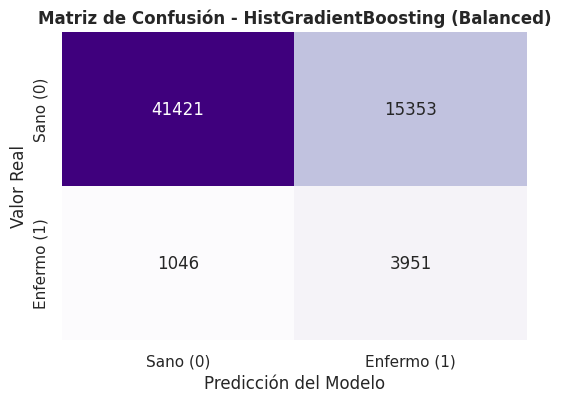

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

print("--- Saneando y alineando matrices de datos ---")

# 1. Eliminamos columnas duplicadas por nombre
X_train_clean = X_train.loc[:, ~X_train.columns.duplicated()]
X_test_clean = X_test.loc[:, ~X_test.columns.duplicated()]

# 2. Reseteamos los índices de las variables objetivo para evitar desalineación de filas
y_train_clean = y_train.reset_index(drop=True)
y_test_clean = y_test.reset_index(drop=True)

# 3. Re-escalamos los datos limpios
X_train_scaled_clean = scaler.fit_transform(X_train_clean)
X_test_scaled_clean = scaler.transform(X_test_clean)

# 4. Reconstruimos los DataFrames asegurando columnas únicas y reseteando índices de filas
X_train_scaled_df = pd.DataFrame(X_train_scaled_clean, columns=X_train_clean.columns).reset_index(drop=True)
X_test_scaled_df = pd.DataFrame(X_test_scaled_clean, columns=X_test_clean.columns).reset_index(drop=True)


print("\n--- Entrenando Modelo Avanzado: HistGradientBoosting (Nativo) ---")

# 5. Inicializamos el Gradient Boosting nativo con pesos balanceados automáticos
modelo_hgb = HistGradientBoostingClassifier(
    max_iter=150,                # Número de árboles secuenciales (equivalente a n_estimators)
    learning_rate=0.05,          # Tasa de aprendizaje
    max_depth=5,                 # Profundidad máxima de cada árbol
    class_weight='balanced',     # ¡El truco nativo para el desbalanceo masivo!
    random_state=42
)

# 6. Entrenamos con las 37 variables originales escaladas y limpias
modelo_hgb.fit(X_train_scaled_df, y_train_clean)

# 7. Realizamos predicciones
y_pred_hgb = modelo_hgb.predict(X_test_scaled_df)


print("\n--- Evaluación de Rendimiento ---")

# 8. Evaluación en pantalla
print(f"Accuracy Global HistGB: {accuracy_score(y_test_clean, y_pred_hgb):.4f}\n")
print("Reporte de Clasificación HistGB:")
print(classification_report(y_test_clean, y_pred_hgb))

# 9. Matriz de Confusión en un tono púrpura/azul elegante
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test_clean, y_pred_hgb), annot=True, fmt='d', cmap='Purples', cbar=False,
            xticklabels=['Sano (0)', 'Enfermo (1)'], yticklabels=['Sano (0)', 'Enfermo (1)'])
plt.title('Matriz de Confusión - HistGradientBoosting (Balanced)', fontweight='bold')
plt.ylabel('Valor Real')
plt.xlabel('Predicción del Modelo')
plt.show()

In [ ]:
# from xgboost import XGBClassifier
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# import seaborn as sns
# import matplotlib.pyplot as plt
# import pandas as pd
# import numpy as np

# print("--- Saneando y alineando matrices de datos para XGBoost ---")

# # 1. Eliminamos columnas duplicadas por nombre (evita conflictos de estructura en XGBoost)
# X_train_clean = X_train.loc[:, ~X_train.columns.duplicated()]
# X_test_clean = X_test.loc[:, ~X_test.columns.duplicated()]

# # 2. Reseteamos los índices de las variables objetivo para evitar desalineación de filas
# y_train_clean = y_train.reset_index(drop=True)
# y_test_clean = y_test.reset_index(drop=True)

# # 3. Re-escalamos los datos limpios (usando el escalador que ya tengas definido)
# X_train_scaled_clean = scaler.fit_transform(X_train_clean)
# X_test_scaled_clean = scaler.transform(X_test_clean)

# # 4. Reconstruimos los DataFrames asegurando columnas únicas y reseteando índices de filas
# X_train_scaled_df = pd.DataFrame(X_train_scaled_clean, columns=X_train_clean.columns).reset_index(drop=True)
# X_test_scaled_df = pd.DataFrame(X_test_scaled_clean, columns=X_test_clean.columns).reset_index(drop=True)


# print("\n--- Calculando pesos para mitigar el desbalanceo ---")

# # 5. Calculamos el ratio exacto: cuántos sanos (0) hay por cada enfermo (1)
# num_sanos = (y_train_clean == 0).sum()
# num_enfermos = (y_train_clean == 1).sum()
# ratio_pesos = num_sanos / num_enfermos
# print(f"Ratio de desbalanceo: {ratio_pesos:.2f} (Cada enfermo pesará {ratio_pesos:.2f} veces más que un sano)")


# print("\n--- Entrenando Modelo Avanzado: XGBoost Balanced ---")

# # 6. Inicializamos XGBoost con hiperparámetros robustos para evitar sobreajuste
# modelo_xgb = XGBClassifier(
#     n_estimators=150,           # Cantidad de árboles secuenciales
#     learning_rate=0.05,         # Tasa de aprendizaje (paso del gradiente)
#     max_depth=5,                # Profundidad máxima de cada árbol
#     scale_pos_weight=ratio_pesos, # El truco mágico que penaliza fallar con un enfermo
#     random_state=42,
#     n_jobs=-1                   # Paraleliza el cálculo usando toda tu CPU
# )

# # 7. Entrenamos con los datos limpios y alineados
# modelo_xgb.fit(X_train_scaled_df, y_train_clean)

# # 8. Realizamos las predicciones sobre el conjunto de test
# y_pred_xgb = modelo_xgb.predict(X_test_scaled_df)


# print("\n--- Evaluación de Rendimiento ---")

# # 9. Evaluación en pantalla
# print(f"Accuracy Global XGBoost: {accuracy_score(y_test_clean, y_pred_xgb):.4f}\n")
# print("Reporte de Clasificación XGBoost:")
# print(classification_report(y_test_clean, y_pred_xgb))

# # 10. Dibujamos la Matriz de Confusión en un tono púrpura elegante
# plt.figure(figsize=(6, 4))
# sns.heatmap(confusion_matrix(y_test_clean, y_pred_xgb), annot=True, fmt='d', cmap='Purples', cbar=False,
#             xticklabels=['Sano (0)', 'Enfermo (1)'], yticklabels=['Sano (0)', 'Enfermo (1)'])
# plt.title('Matriz de Confusión - XGBoost (Balanced)', fontweight='bold')
# plt.ylabel('Valor Real')
# plt.xlabel('Predicción del Modelo')
# plt.show()

# 9. Aprendizaje No Supervisado Avanzado: Reducción Dimensional con Autoencoders

Tras analizar las limitaciones del **PCA** (que solo captura relaciones lineales y ortogonales) y el comportamiento geométrico del **t-SNE** (que desveló una densa nube de datos solapada), daremos el salto a una técnica de vanguardia basada en Redes Neuronales Artificiales: los **Autoencoders** (Auto-codificadores).

---

### 🧠 ¿Qué es un Autoencoder y cómo funciona?

Un Autoencoder es una arquitectura de red neuronal que se entrena de forma **no supervisada** (sin mirar la variable objetivo `y`). Su meta principal es aprender a copiar sus entradas a sus salidas, pero pasando obligatoriamente por una "restricción" central de espacio.

Su estructura se divide en tres componentes críticos:

1. **El Encoder (Codificador):** Toma las 37 variables originales del paciente y, mediante capas densas con funciones de activación no lineales (como ReLU), comprime gradualmente la información reduciendo el número de neuronas.
2. **El Bottleneck / Latent Space (Espacio Latente o Cuello de Botella):** Es la capa central de la red y la más pequeña. Aquí la información original se reduce a un espacio hiper-comprimido (por ejemplo, 17 componentes, para poder compararlo directamente con el PCA). Al obligar a la red a pasar por este embudo, la forzamos a destruir el ruido y a quedarse únicamente con las características esenciales y más profundas de la salud del paciente.
3. **El Decoder (Decodificador):** Toma las neuronas del espacio latente e intenta hacer el proceso inverso: reconstruir las 37 variables originales.



[Image of autoencoder neural network architecture]


---

### 🩺 ¿Por qué usarlo en nuestro Dataset Médico?

A diferencia del PCA, que traza proyecciones en línea recta, el Autoencoder utiliza funciones de activación no lineales. Esto le permite doblar, curvar y retorcer el espacio matemático para capturar las interacciones complejas y ocultas entre variables (por ejemplo, cómo se relacionan la Diabetes, el BMI y la Edad a niveles microscópicos). 

Su objetivo final en este proyecto es generar un conjunto de **componentes latentes de calidad superior** que ayuden a la Regresión Logística o a los modelos de Boosting a separar mejor a los pacientes sanos de los enfermos.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

print("--- Saneando y preparando datos para el Autoencoder ---")
# 1. Limpieza de columnas e índices para evitar desalineaciones
X_train_clean = X_train.loc[:, ~X_train.columns.duplicated()]
X_test_clean = X_test.loc[:, ~X_test.columns.duplicated()]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clean)
X_test_scaled = scaler.transform(X_test_clean)

# Dimensiones de entrada (las 37 variables originales)
dim_entrada = X_train_scaled.shape[1] 
# Dimensión latente (fijamos 17 para comparar justamente contra tus 17 componentes del PCA)
dim_latente = 17 

print(f"Dimensiones de entrada: {dim_entrada} | Dimensión latente objetivo: {dim_latente}")


print("\n--- Diseñando la Arquitectura del Autoencoder ---")
# 2. CAPA DE ENTRADA
input_layer = Input(shape=(dim_entrada,), name="Entrada_Original")

# 3. ENCODER (Compresión gradual)
encoder_layer1 = Dense(26, activation='relu', name="Encoder_CapaOculta")(input_layer)
latent_space = Dense(dim_latente, activation='relu', name="Espacio_Latente_Bottleneck")(encoder_layer1)

# 4. DECODER (Reconstrucción gradual)
decoder_layer1 = Dense(26, activation='relu', name="Decoder_CapaOculta")(latent_space)
output_layer = Dense(dim_entrada, activation='linear', name="Salida_Reconstruida")(decoder_layer1)

# 5. ENSAMBLE DEL AUTOENCODER COMPLETO
autoencoder = Model(inputs=input_layer, outputs=output_layer, name="Autoencoder_Completo")
autoencoder.compile(optimizer='adam', loss='mse') # Minimizamos el Error Cuadrático Medio

autoencoder.summary()


print("\n--- Entrenando el Autoencoder ---")
# Nota: Como es NO SUPERVISADO, la 'y' de entrenamiento es la propia 'X'
history = autoencoder.fit(
    X_train_scaled, X_train_scaled,
    epochs=15,
    batch_size=256,
    validation_split=0.2,
    verbose=1
)


print("\n--- Extrayendo las Variables Comprimidas (Espacio Latente) ---")
# 6. Creamos un modelo intermedio que corte la red justo en el Bottleneck
encoder_puro = Model(inputs=input_layer, outputs=latent_space, name="Encoder_Extractor")

# 7. Transformamos nuestros datasets originales en las nuevas 17 variables neuronales
X_train_autoencoder = encoder_puro.predict(X_train_scaled)
X_test_autoencoder = encoder_puro.predict(X_test_scaled)


# =====================================================================
# GRAFICAMOS LA CURVA DE APRENDIZAJE (LOSS)
# =====================================================================
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Error Entrenamiento (Loss)', color='teal', linewidth=2)
plt.plot(history.history['val_loss'], label='Error Validación (Val Loss)', color='crimson', linewidth=2)
plt.title('Historial de Entrenamiento del Autoencoder', fontsize=12, fontweight='bold')
plt.xlabel('Épocas de Entrenamiento')
plt.ylabel('Pérdida (MSE)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

print("-> ¡Extracción completada! 'X_train_autoencoder' listo para alimentar modelos.")

# 9.3. Postprocesado e Interpretabilidad del Espacio Latente mediante SHAP

Uno de los mayores desafíos al implementar un **Autoencoder** es la pérdida de interpretabilidad clínica. Las 17 nuevas variables extraídas del espacio latente (`X_train_autoencoder`) son combinaciones matemáticas complejas y abstractas. Para un cardiólogo en un hospital, una variable llamada `Componente_Latente_0` no significa nada.

Para solucionar esto y auditar nuestra red neuronal, utilizaremos **SHAP** (valores de Shapley), una técnica basada en la teoría de juegos cooperativos que mide el impacto y la contribución exacta de cada una de las 37 variables originales sobre la generación de las nuevas variables de nuestro espacio latente. Esto nos permitirá mapear la equivalencia clínica de nuestras neuronas.

In [ ]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("--- Preparando el explicador SHAP para el Autoencoder ---")

# 1. Para evitar que tarde horas, seleccionamos una muestra representativa de 500 pacientes
muestra_background = shap.utils.sample(X_train_scaled_df, 500, random_state=42)
muestra_test = shap.utils.sample(X_test_scaled_df, 100, random_state=42)

# 2. Creamos una función puente que tome las 37 variables y devuelva SOLO el Componente Latente 0
def predecir_componente_0(X_input):
    # Convertimos a array si es DataFrame
    X_arr = np.array(X_input)
    # Pasamos por el encoder puro que entrenamos en la celda anterior
    componentes_latentes = encoder_puro.predict(X_arr, verbose=0)
    # Devolvemos únicamente la primera columna (Componente 0)
    return componentes_latentes[:, 0]

# 3. Inicializamos el explicador KernelExplainer de SHAP
explicador_shap = shap.KernelExplainer(predecir_componente_0, muestra_background)

print("\n--- Calculando valores SHAP (Este proceso puede tomar 1 o 2 minutos) ---")
valores_shap = explicador_shap.shap_values(muestra_test)

# =====================================================================
# GENERACIÓN DEL GRÁFICO SUMMARY PLOT DE SHAP
# =====================================================================
plt.figure(figsize=(10, 6))
plt.title("Importancia de Variables Originales en el Componente Latente 0 (Autoencoder)", fontsize=12, fontweight='bold', pad=20)

# Pintamos el gráfico de barras clásico de SHAP para ver la importancia global
shap.summary_plot(valores_shap, muestra_test, plot_type="bar", show=False)

plt.xlabel("Impacto medio en el valor de salida (SHAP value)", fontsize=11)
plt.tight_layout()
plt.show()